# 🚢 Titanic: Análise Exploratória, Inferência Estatística e Predição de Sobrevivência

O naufrágio do RMS Titanic, em **15 de abril de 1912**, durante a viagem inaugural de Southampton a Nova York, matou mais de 1.500 pessoas. Os botes salva-vidas só acomodavam cerca de metade dos que estavam a bordo, e a forma como esses lugares foram ocupados deixou marcas profundas nos dados.

Este notebook é o material prático da aula **"Titanic: da análise exploratória à predição"** e usa os dados do clássico desafio [Titanic: Machine Learning from Disaster](https://www.kaggle.com/competitions/titanic) do Kaggle. Ele foi pensado para ser lido de cima para baixo e para que cada trecho de código possa ser executado e reproduzido pelos alunos.

### Perguntas que queremos responder
1. Quais fatores demográficos (**sexo, idade, classe**) mais pesaram na sobrevivência?
2. A **tarifa** e o **porto de embarque** influenciaram, ou apenas refletem outras variáveis?
3. O **tamanho da família** (ou do grupo de viagem) importou?
4. É possível construir um **modelo preditivo** confiável? Quão bom ele é, de verdade, comparado a uma regra simples?

### Roteiro
| Parte | Conteúdo |
|---|---|
| 1 | Configuração e carga dos dados |
| 2 | Visão geral e qualidade dos dados (valores ausentes) |
| 3 | Análise univariada |
| 4 | Análise bivariada e multivariada (com intervalos de confiança) |
| 5 | Engenharia de atributos (título, família, convés, bilhete) |
| 6 | Tratamento de idades ausentes |
| 7 | Inferência estatística (qui-quadrado, odds ratio, regressão logística, interações) |
| 8 | Correlações e informação mútua |
| 9 | Modelagem preditiva (validação cruzada, ajuste, teste final) |
| 10 | Diagnóstico do modelo (importância, limiar, erros) |
| 11 | **Resenha dos resultados** |

**Como citar este material**

> COIMBRA, Paulo C. **Titanic: da análise exploratória à predição de sobrevivência**: material didático (notebook, página de aula e artigo). Juiz de Fora: UFJF, 2026. Disponível em: https://github.com/pauloccoimbra/titanic-eda-ml-aula.

```bibtex
@misc{coimbra2026titanic,
  author = {Coimbra, Paulo C.},
  title  = {Titanic: da an{\'a}lise explorat{\'o}ria {\`a} predi{\c c}{\~a}o de sobreviv{\^e}ncia: material did{\'a}tico},
  year   = {2026},
  howpublished = {\url{https://github.com/pauloccoimbra/titanic-eda-ml-aula}},
  note   = {Licen{\c c}as: MIT (c{\'o}digo) e CC BY 4.0 (textos)}
}
```
Licenças: código sob **MIT**; textos, figuras e comentários sob **CC BY 4.0**. Dados: `train.csv` da competição [Titanic do Kaggle](https://www.kaggle.com/competitions/titanic), de uso educacional.

## 1. Configuração e carga dos dados

Primeiro importamos as bibliotecas e definimos um estilo visual único para todo o notebook (duas cores fixas: **vermelho = morreu**, **azul = sobreviveu**), para que os gráficos sejam lidos de forma consistente.

In [1]:
# --- Bibliotecas ---------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")          # deixa a saída limpa (avisos de versão não afetam os resultados)

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_validate, cross_val_predict, GridSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             brier_score_loss, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             precision_recall_curve, classification_report)

# --- Estilo visual -----------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
COR_MORREU, COR_SOBREVIVEU = "#d1495b", "#2e86ab"
PALETA_SOBREV = {0: COR_MORREU, 1: COR_SOBREVIVEU}
SEED = 42                                   # semente para reprodutibilidade
np.random.seed(SEED)

### Carregando os dados
O arquivo é o `train.csv` do Kaggle (891 passageiros, 12 colunas). O código tenta, em ordem: (1) um arquivo local `titanic.csv`/`train.csv`; (2) algumas URLs públicas. Se nenhuma funcionar (por exemplo, sem internet), basta colocar o `train.csv` na mesma pasta do notebook.

In [2]:
import os
FONTES = ["titanic.csv", "train.csv",
          "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv",
          "https://d17h27t6h515a5.cloudfront.net/topher/2016/September/57e9a84c_titanic-data/titanic-data.csv"]

df_raw = None
for fonte in FONTES:
    try:
        if not fonte.startswith("http") and not os.path.exists(fonte):
            continue
        df_raw = pd.read_csv(fonte)
        print(f"✅ Dados carregados de: {fonte}")
        break
    except Exception as e:
        print(f"⚠️ Falhou ({fonte[:60]}...): {type(e).__name__}")
if df_raw is None:
    raise FileNotFoundError("Não foi possível carregar os dados. Coloque 'train.csv' do Kaggle na pasta do notebook.")

df = df_raw.copy()          # trabalhamos sempre numa cópia; o original fica intacto
print("Dimensões (linhas, colunas):", df.shape)
df.head()

✅ Dados carregados de: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Dimensões (linhas, colunas): (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dicionário de dados**

| Coluna | Significado |
|---|---|
| `PassengerId` | identificador |
| `Survived` | **alvo**: 1 = sobreviveu, 0 = morreu |
| `Pclass` | classe da passagem (1 = alta, 2 = média, 3 = baixa) |
| `Name` | nome (contém o **título**: Mr., Mrs., Miss., Master. etc.) |
| `Sex` | sexo |
| `Age` | idade em anos (frações para bebês) |
| `SibSp` | nº de irmãos/cônjuges a bordo |
| `Parch` | nº de pais/filhos a bordo |
| `Ticket` | número do bilhete (grupos viajam com o mesmo bilhete) |
| `Fare` | tarifa paga (£) |
| `Cabin` | cabine (muito incompleta; a letra indica o convés) |
| `Embarked` | porto: C = Cherbourg, Q = Queenstown, S = Southampton |

## 2. Visão geral e qualidade dos dados

Antes de qualquer gráfico, convém saber **o que existe e o que falta**. Dados ausentes raramente são aleatórios, e isso pode enviesar conclusões.

In [3]:
# Tipos de dados, valores únicos e ausentes, lado a lado
resumo = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes": df.isna().sum(),
    "% ausentes": (df.isna().mean() * 100).round(1),
    "valores únicos": df.nunique(),
})
display(resumo)
print("Linhas duplicadas:", df.duplicated().sum())
print("PassengerId únicos:", df["PassengerId"].is_unique)

,tipo,ausentes,% ausentes,valores únicos
PassengerId,int64,0,0.0,891
Survived,int64,0,0.0,2
Pclass,int64,0,0.0,3
Name,str,0,0.0,891
Sex,str,0,0.0,2
Age,float64,177,19.9,88
SibSp,int64,0,0.0,7
Parch,int64,0,0.0,7
Ticket,str,0,0.0,681
Fare,float64,0,0.0,248


Linhas duplicadas: 0
PassengerId únicos: True


In [4]:
# Estatísticas descritivas das variáveis numéricas
df[["Age", "SibSp", "Parch", "Fare"]].describe().round(2)

,Age,SibSp,Parch,Fare
count,714.00,891.00,891.00,891.00
mean,29.70,0.52,0.38,32.20
std,14.53,1.10,0.81,49.69
min,0.42,0.00,0.00,0.00
25%,20.12,0.00,0.00,7.91
50%,28.00,0.00,0.00,14.45
75%,38.00,1.00,0.00,31.00
max,80.00,8.00,6.00,512.33


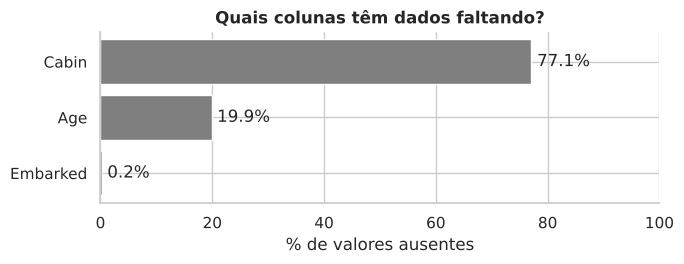

In [5]:
# Gráfico dos valores ausentes
ausentes = (df.isna().mean() * 100).sort_values(ascending=False)
ausentes = ausentes[ausentes > 0]
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(ausentes.index[::-1], ausentes.values[::-1], color="#7f7f7f")
for i, v in enumerate(ausentes.values[::-1]):
    ax.text(v + 1, i, f"{v:.1f}%", va="center")
ax.set_xlim(0, 100); ax.set_xlabel("% de valores ausentes")
ax.set_title("Quais colunas têm dados faltando?")
plt.tight_layout(); plt.show()

### Os dados ausentes são aleatórios?
`Cabin` (77% ausente) e `Age` (20% ausente) são os casos importantes. Vamos checar se estar "ausente" se associa à classe ou à sobrevivência. Se sim, o mecanismo de ausência carrega informação (e não deve ser simplesmente ignorado).

In [6]:
taxa_geral = df["Survived"].mean()
print(f"Taxa geral de sobrevivência: {taxa_geral:.1%}\n")

df["_cabine_conhecida"] = df["Cabin"].notna()
df["_idade_conhecida"] = df["Age"].notna()

print("→ Cabine conhecida × classe (% com cabine registrada):")
print((df.groupby("Pclass")["_cabine_conhecida"].mean() * 100).round(1).to_string(), "\n")
print("→ Taxa de sobrevivência segundo cabine registrada:")
print(df.groupby("_cabine_conhecida")["Survived"].mean().round(3).rename({False: "sem cabine", True: "com cabine"}).to_string(), "\n")
print("→ Idade ausente × classe (% sem idade):")
print(((1 - df.groupby("Pclass")["_idade_conhecida"].mean()) * 100).round(1).to_string(), "\n")
print("→ Taxa de sobrevivência segundo idade registrada:")
print(df.groupby("_idade_conhecida")["Survived"].mean().round(3).rename({False: "sem idade", True: "com idade"}).to_string())
df = df.drop(columns=["_cabine_conhecida", "_idade_conhecida"])

Taxa geral de sobrevivência: 38.4%

→ Cabine conhecida × classe (% com cabine registrada):
Pclass
1    81.5
2     8.7
3     2.4 

→ Taxa de sobrevivência segundo cabine registrada:
_cabine_conhecida
sem cabine    0.300
com cabine    0.667 

→ Idade ausente × classe (% sem idade):
Pclass
1    13.9
2     6.0
3    27.7 

→ Taxa de sobrevivência segundo idade registrada:
_idade_conhecida
sem idade    0.294
com idade    0.406


**Leitura:** a cabine só foi registrada para quem, em geral, estava na 1ª classe (e, entre os registrados, sobreviveu bem mais). As idades ausentes concentram-se na 3ª classe. Ou seja, **a ausência não é aleatória**: ela está ligada à classe social, o que justifica criar um indicador `HasCabin` e um indicador de idade ausente mais adiante.

## 3. Análise univariada

Olhamos uma variável de cada vez: como estão distribuídas as pessoas a bordo?

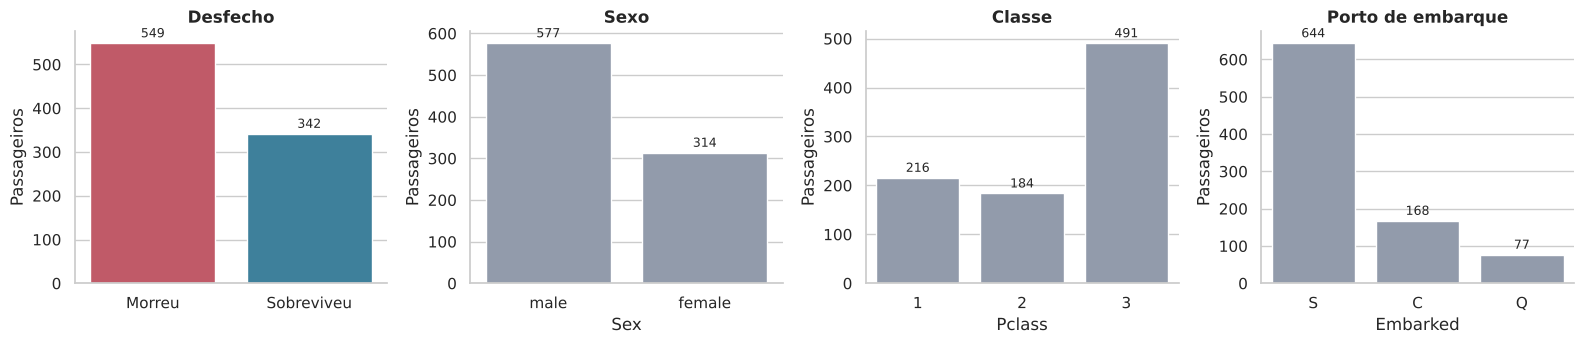

Proporções:
  Survived  {0: 61.6, 1: 38.4}
  Sex       {'male': 64.8, 'female': 35.199999999999996}
  Pclass    {3: 55.1, 1: 24.2, 2: 20.7}
  Embarked  {'S': 72.39999999999999, 'C': 18.9, 'Q': 8.7}


In [7]:
# 3.1 Variáveis categóricas: quantas pessoas em cada categoria?
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6))
rotulos_sobrev = df["Survived"].map({0: "Morreu", 1: "Sobreviveu"})
sns.countplot(x=rotulos_sobrev, order=["Morreu", "Sobreviveu"], palette=[COR_MORREU, COR_SOBREVIVEU], ax=axes[0])
axes[0].set_title("Desfecho"); axes[0].set_xlabel("")
sns.countplot(x="Sex", data=df, order=["male", "female"], color="#8e9aaf", ax=axes[1]); axes[1].set_title("Sexo")
sns.countplot(x="Pclass", data=df, color="#8e9aaf", ax=axes[2]); axes[2].set_title("Classe")
sns.countplot(x="Embarked", data=df, order=["S", "C", "Q"], color="#8e9aaf", ax=axes[3]); axes[3].set_title("Porto de embarque")
for ax in axes:
    ax.set_ylabel("Passageiros")
    for c in ax.containers:
        ax.bar_label(c, padding=2, fontsize=9)
plt.tight_layout(); plt.show()

print("Proporções:")
for col in ["Survived", "Sex", "Pclass", "Embarked"]:
    print(f"  {col:9s}", (df[col].value_counts(normalize=True).round(3) * 100).to_dict())

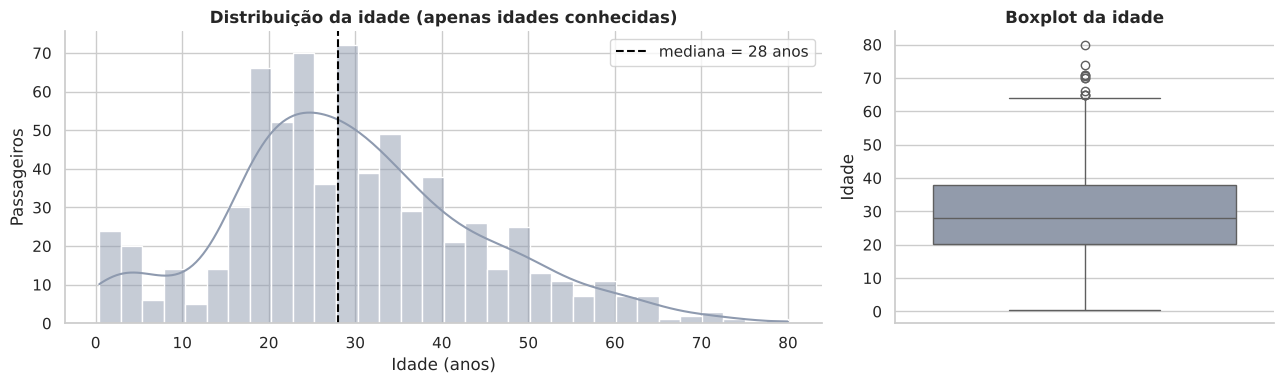

Assimetria (skew) da idade: 0.39  |  crianças (<13): 69  |  idosos (≥60): 26


In [8]:
# 3.2 Idade: histograma + densidade e boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 4), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(df["Age"].dropna(), bins=32, kde=True, color="#8e9aaf", ax=axes[0])
axes[0].axvline(df["Age"].median(), color="black", ls="--", label=f"mediana = {df['Age'].median():.0f} anos")
axes[0].set(title="Distribuição da idade (apenas idades conhecidas)", xlabel="Idade (anos)", ylabel="Passageiros"); axes[0].legend()
sns.boxplot(y=df["Age"], color="#8e9aaf", ax=axes[1]); axes[1].set(title="Boxplot da idade", ylabel="Idade")
plt.tight_layout(); plt.show()
print(f"Assimetria (skew) da idade: {df['Age'].skew():.2f}  |  crianças (<13): {(df['Age']<13).sum()}  |  idosos (≥60): {(df['Age']>=60).sum()}")

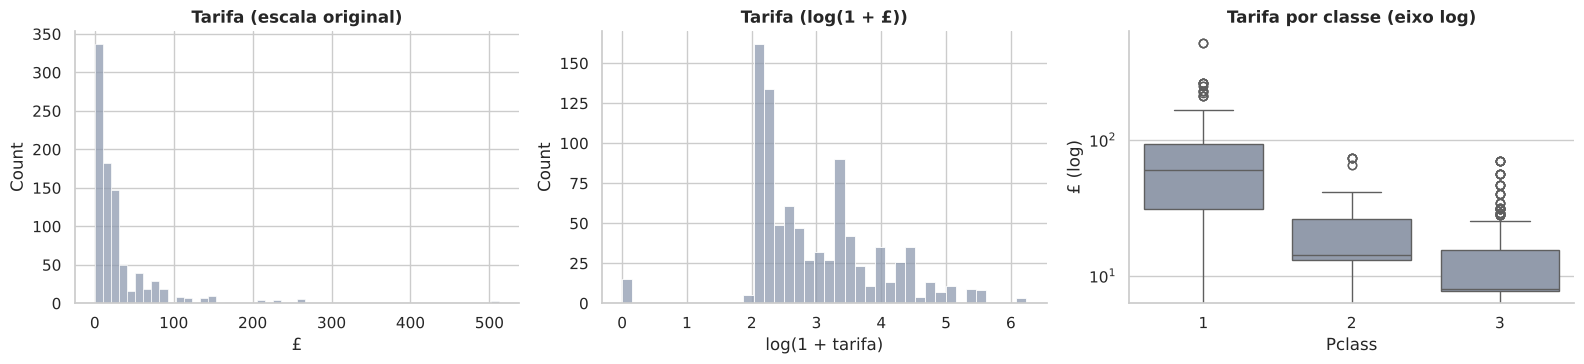

Assimetria da tarifa: 4.79  → após log1p: 0.39
Tarifas iguais a zero: 15 (tripulação/convidados? provavelmente casos especiais)
                              Name  Pclass     Fare  Survived
            Lesurer, Mr. Gustave J       1 512.3292         1
Cardeza, Mr. Thomas Drake Martinez       1 512.3292         1
                  Ward, Miss. Anna       1 512.3292         1
                 Fortune, Mr. Mark       1 263.0000         0
        Fortune, Miss. Mabel Helen       1 263.0000         1


In [9]:
# 3.3 Tarifa: muito assimétrica → a escala logarítmica ajuda a enxergar
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
sns.histplot(df["Fare"], bins=50, color="#8e9aaf", ax=axes[0]); axes[0].set(title="Tarifa (escala original)", xlabel="£")
sns.histplot(np.log1p(df["Fare"]), bins=40, color="#8e9aaf", ax=axes[1]); axes[1].set(title="Tarifa (log(1 + £))", xlabel="log(1 + tarifa)")
sns.boxplot(x="Pclass", y="Fare", data=df, color="#8e9aaf", ax=axes[2]); axes[2].set_yscale("log"); axes[2].set(title="Tarifa por classe (eixo log)", ylabel="£ (log)")
plt.tight_layout(); plt.show()
print(f"Assimetria da tarifa: {df['Fare'].skew():.2f}  → após log1p: {np.log1p(df['Fare']).skew():.2f}")
print(f"Tarifas iguais a zero: {(df['Fare']==0).sum()} (tripulação/convidados? provavelmente casos especiais)")
print(df.sort_values("Fare", ascending=False)[["Name", "Pclass", "Fare", "Survived"]].head(5).to_string(index=False))

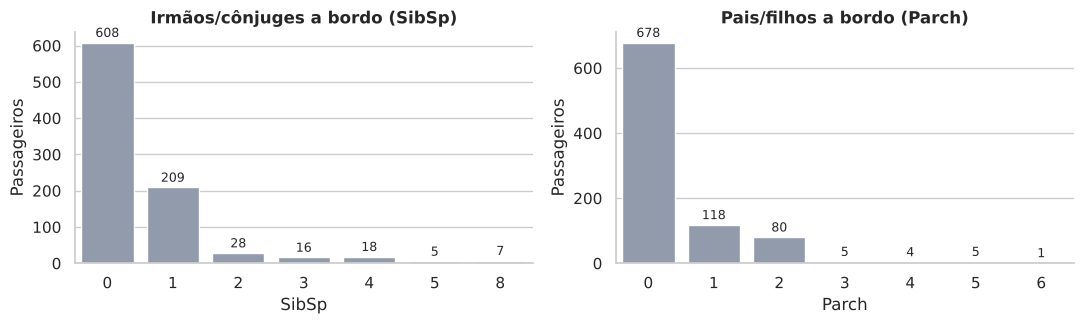

In [10]:
# 3.4 Família: SibSp e Parch
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
sns.countplot(x="SibSp", data=df, color="#8e9aaf", ax=axes[0]); axes[0].set_title("Irmãos/cônjuges a bordo (SibSp)")
sns.countplot(x="Parch", data=df, color="#8e9aaf", ax=axes[1]); axes[1].set_title("Pais/filhos a bordo (Parch)")
for ax in axes:
    for c in ax.containers: ax.bar_label(c, padding=2, fontsize=9)
    ax.set_ylabel("Passageiros")
plt.tight_layout(); plt.show()

**Leitura:** só ~38% sobreviveram; havia quase 2 homens para cada mulher; a maioria viajava na 3ª classe e embarcou em Southampton; a maior parte viajava sozinha ou em grupos pequenos. A tarifa é muito assimétrica (poucos pagaram fortunas), então usaremos `log(1 + tarifa)` nos modelos.

## 4. Análise bivariada e multivariada

Agora cruzamos cada variável com a sobrevivência. Para não superinterpretar diferenças em grupos pequenos, **todas as taxas vêm com intervalo de confiança de 95%** (método de Wilson). A linha tracejada é a taxa geral (38,4%).

In [11]:
# --- Funções auxiliares reutilizadas ao longo do notebook ------------------
def wilson(k, n, z=1.96):
    """Intervalo de confiança de Wilson (95%) para uma proporção k/n."""
    if n == 0:
        return np.nan, np.nan
    p = k / n
    den = 1 + z**2 / n
    centro = (p + z**2 / (2 * n)) / den
    meia = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / den
    return centro - meia, centro + meia

def taxa_sobrevivencia(dados, col):
    """Tabela com n, sobreviventes, taxa e IC95% por categoria de `col`."""
    g = dados.groupby(col, observed=True)["Survived"].agg(n="size", sobreviventes="sum")
    g["taxa"] = g["sobreviventes"] / g["n"]
    ic = g.apply(lambda r: wilson(r["sobreviventes"], r["n"]), axis=1, result_type="expand")
    g["ic_inf"], g["ic_sup"] = ic[0], ic[1]
    return g

def plot_taxa(dados, col, ax, titulo=None, ordem=None, rot=0, cor=COR_SOBREVIVEU):
    """Barras da taxa de sobrevivência por categoria, com IC95% e tamanho do grupo."""
    g = taxa_sobrevivencia(dados, col)
    if ordem is not None:
        g = g.loc[ordem]
    x = np.arange(len(g))
    ax.bar(x, g["taxa"], color=cor, alpha=0.85)
    ax.errorbar(x, g["taxa"], yerr=[g["taxa"] - g["ic_inf"], g["ic_sup"] - g["taxa"]],
                fmt="none", ecolor="black", capsize=4, lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i}\n(n={n})" for i, n in zip(g.index, g["n"])], rotation=rot)
    for xi, t in zip(x, g["taxa"]):
        ax.text(xi, 0.03, f"{t:.0%}", ha="center", color="white", fontweight="bold")
    ax.axhline(dados["Survived"].mean(), ls="--", color="gray", lw=1)
    ax.set_ylim(0, 1.02); ax.set_ylabel("Taxa de sobrevivência"); ax.set_xlabel("")
    ax.set_title(titulo or col)
    return g

### 4.1 Os três fatores clássicos: sexo, classe e porto

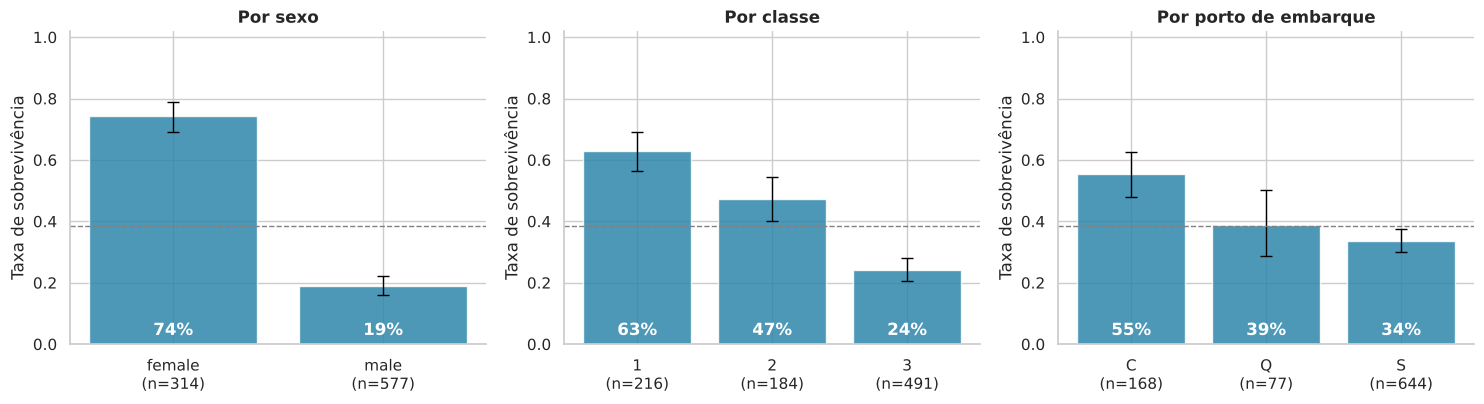

,n,sobreviventes,taxa,ic_inf,ic_sup
Sex,,,,,
female,314,233,0.742,0.691,0.787
male,577,109,0.189,0.159,0.223


,n,sobreviventes,taxa,ic_inf,ic_sup
Pclass,,,,,
1,216,136,0.630,0.563,0.691
2,184,87,0.473,0.402,0.545
3,491,119,0.242,0.207,0.282


,n,sobreviventes,taxa,ic_inf,ic_sup
Embarked,,,,,
C,168,93,0.554,0.478,0.627
Q,77,30,0.390,0.288,0.501
S,644,217,0.337,0.302,0.374


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
g_sex = plot_taxa(df, "Sex", axes[0], "Por sexo", ordem=["female", "male"])
g_cls = plot_taxa(df, "Pclass", axes[1], "Por classe")
g_emb = plot_taxa(df, "Embarked", axes[2], "Por porto de embarque", ordem=["C", "Q", "S"])
plt.tight_layout(); plt.show()
display(g_sex.round(3)); display(g_cls.round(3)); display(g_emb.round(3))

**Leitura:** a diferença de sexo é enorme (~74% das mulheres contra ~19% dos homens). A taxa cai monotonicamente com a classe (63% → 47% → 24%). Cherbourg parece "melhor" que Southampton, mas isso pode ser um efeito de composição (quem embarcou onde). Testaremos isso adiante.

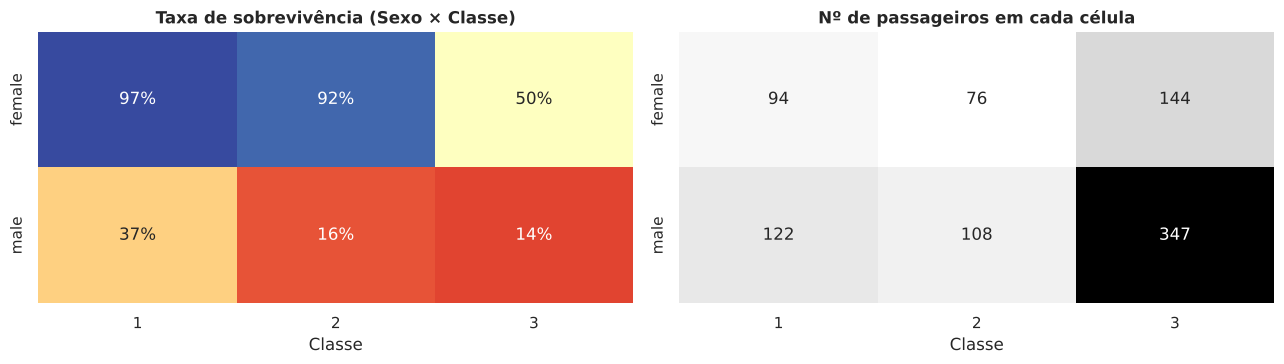

In [13]:
# 4.2 Sexo × Classe: o cruzamento que mais explica o desfecho
tab = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean")
cont = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="size")
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
sns.heatmap(tab.loc[["female", "male"]], annot=True, fmt=".0%", cmap="RdYlBu", vmin=0, vmax=1, cbar=False, ax=axes[0])
axes[0].set(title="Taxa de sobrevivência (Sexo × Classe)", xlabel="Classe", ylabel="")
sns.heatmap(cont.loc[["female", "male"]], annot=True, fmt="d", cmap="Greys", cbar=False, ax=axes[1])
axes[1].set(title="Nº de passageiros em cada célula", xlabel="Classe", ylabel="")
plt.tight_layout(); plt.show()

**Leitura:** entre as mulheres de 1ª e 2ª classe, 97% e 92% sobreviveram; já as **mulheres de 3ª classe sobreviveram em apenas 50%**. Os homens de 2ª e 3ª classe ficaram em 16% e 14%, e os de 1ª classe em 37%. Sexo e classe **interagem**: a vantagem de ser mulher foi enorme nas classes altas e bem menor na 3ª (testamos isso formalmente na Parte 7.6).

### 4.3 Idade

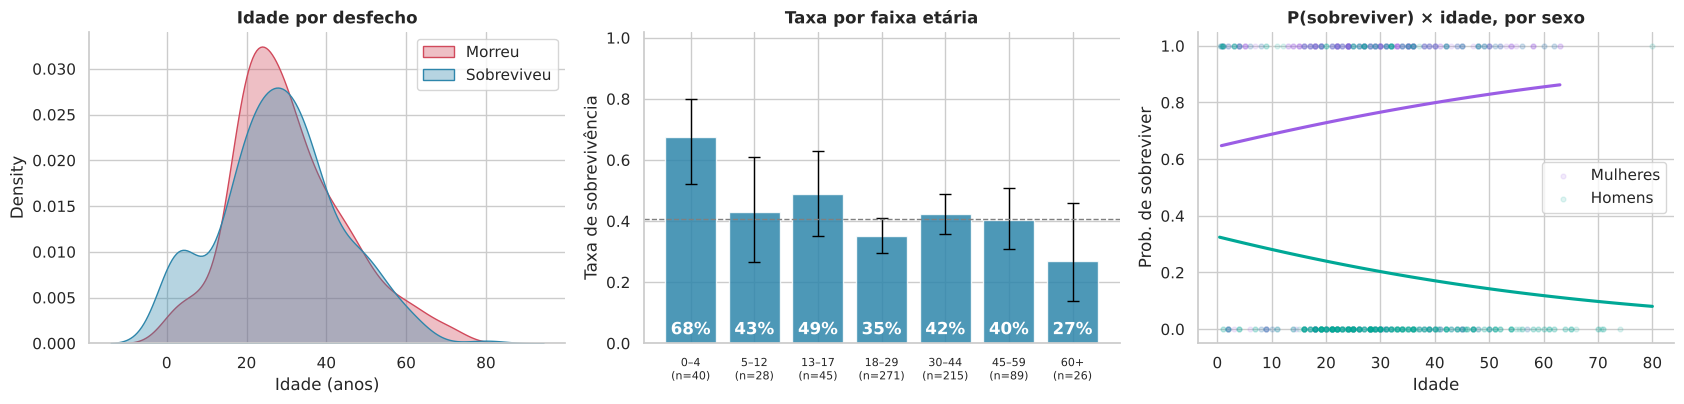

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

# (a) densidades de idade por desfecho
for s, nome in [(0, "Morreu"), (1, "Sobreviveu")]:
    sns.kdeplot(df.loc[df["Survived"] == s, "Age"].dropna(), fill=True, alpha=0.35, color=PALETA_SOBREV[s], label=nome, ax=axes[0])
axes[0].set(title="Idade por desfecho", xlabel="Idade (anos)"); axes[0].legend()

# (b) faixas etárias
faixas = [0, 5, 12, 18, 30, 45, 60, 81]
rot_faixas = ["0–4", "5–12", "13–17", "18–29", "30–44", "45–59", "60+"]
df["FaixaEtaria"] = pd.cut(df["Age"], bins=faixas, labels=rot_faixas, right=False)
plot_taxa(df.dropna(subset=["FaixaEtaria"]), "FaixaEtaria", axes[1], "Taxa por faixa etária", ordem=rot_faixas, rot=0)
axes[1].tick_params(axis="x", labelsize=8)

# (c) idade × sexo: a "regra de mulheres e crianças" aparece?
for sexo, cor in [("female", "#9b5de5"), ("male", "#00a896")]:
    d = df[df["Sex"] == sexo].dropna(subset=["Age"])
    sns.regplot(x="Age", y="Survived", data=d, logistic=True, scatter_kws={"alpha": 0.12, "s": 12}, color=cor,
                label={"female": "Mulheres", "male": "Homens"}[sexo], ax=axes[2], ci=None, truncate=True)
axes[2].set(title="P(sobreviver) × idade, por sexo", xlabel="Idade", ylabel="Prob. de sobreviver"); axes[2].legend()
plt.tight_layout(); plt.show()

**Leitura:** crianças de 0–4 anos tiveram a maior taxa de sobrevivência (68%); adultos de 18–29 anos ficaram em 35% e os de 60+ em 27% (n = 26, intervalo largo). As curvas logísticas mostram inclinações **opostas** por sexo: entre os homens, quanto mais velho, menor a chance (coeficiente negativo, p ≈ 0,01); entre as mulheres a curva é plana ou levemente crescente (p ≈ 0,06). Isso é coerente com "mulheres e crianças primeiro", e não com uma simples queda geral com a idade.

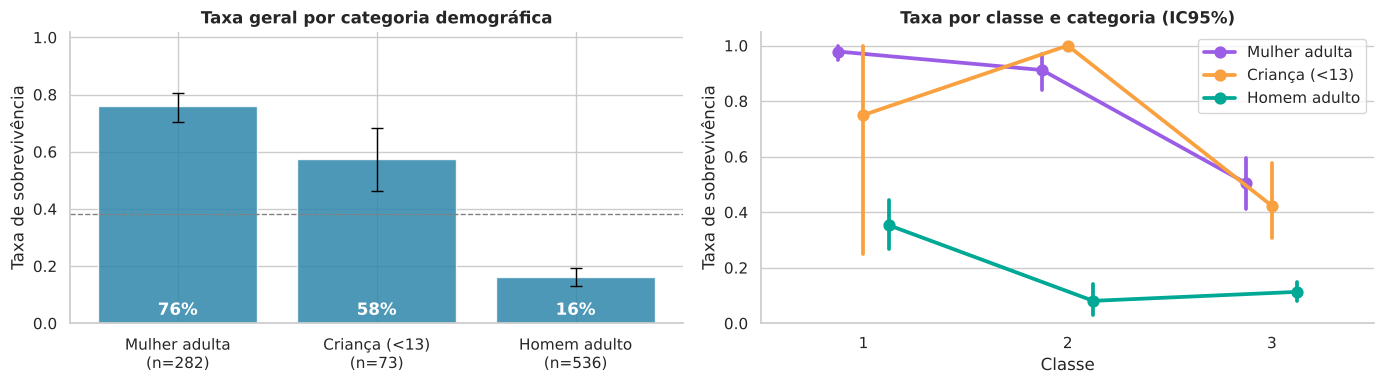

Pclass,Classe 1,Classe 2,Classe 3
Mulher adulta,0.98,0.91,0.50
Criança (<13),0.75,1.00,0.42
Homem adulto,0.35,0.08,0.11


Pclass,"n, classe 1","n, classe 2","n, classe 3"
Mulher adulta,93,68,121
Criança (<13),4,17,52
Homem adulto,119,99,318


In [15]:
# 4.4 "Mulheres e crianças primeiro?": criamos uma categoria demográfica e olhamos por classe
def categoria_demografica(r):
    if (pd.notna(r["Age"]) and r["Age"] < 13) or (pd.isna(r["Age"]) and "Master." in r["Name"]):
        return "Criança (<13)"
    return "Mulher adulta" if r["Sex"] == "female" else "Homem adulto"

df["CatDemog"] = df.apply(categoria_demografica, axis=1)
ordem_cat = ["Mulher adulta", "Criança (<13)", "Homem adulto"]
tab_cd = df.pivot_table(index="CatDemog", columns="Pclass", values="Survived", aggfunc=["mean", "size"]).loc[ordem_cat]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_taxa(df, "CatDemog", axes[0], "Taxa geral por categoria demográfica", ordem=ordem_cat)
sns.pointplot(data=df, x="Pclass", y="Survived", hue="CatDemog", hue_order=ordem_cat,
              palette=["#9b5de5", "#f9a03f", "#00a896"], errorbar=("ci", 95), dodge=0.25, ax=axes[1])
axes[1].set(title="Taxa por classe e categoria (IC95%)", xlabel="Classe", ylabel="Taxa de sobrevivência", ylim=(0, 1.05))
axes[1].legend(title="")
plt.tight_layout(); plt.show()
display((tab_cd["mean"].round(2)).rename_axis(None).add_prefix("Classe "))
display(tab_cd["size"].rename_axis(None).add_prefix("n, classe "))

**Leitura:** mulheres adultas sobreviveram em 76%, crianças (<13) em 58% e homens adultos em 16%. Mas a proteção variou por classe: mulheres adultas de 1ª e 2ª classe tiveram 98% e 91%, contra 50% na 3ª; e **crianças de 3ª classe sobreviveram em apenas 42%** (n = 52), enquanto as de 2ª classe sobreviveram todas (n = 17). "Mulheres e crianças primeiro" valeu plenamente nas classes altas e muito menos na 3ª. (Atenção: as células de crianças em 1ª classe têm só 4 pessoas.)

### 4.5 Tarifa
A tarifa e a classe estão muito ligadas. A pergunta interessante é: **a tarifa tem efeito próprio, depois de descontada a classe?**

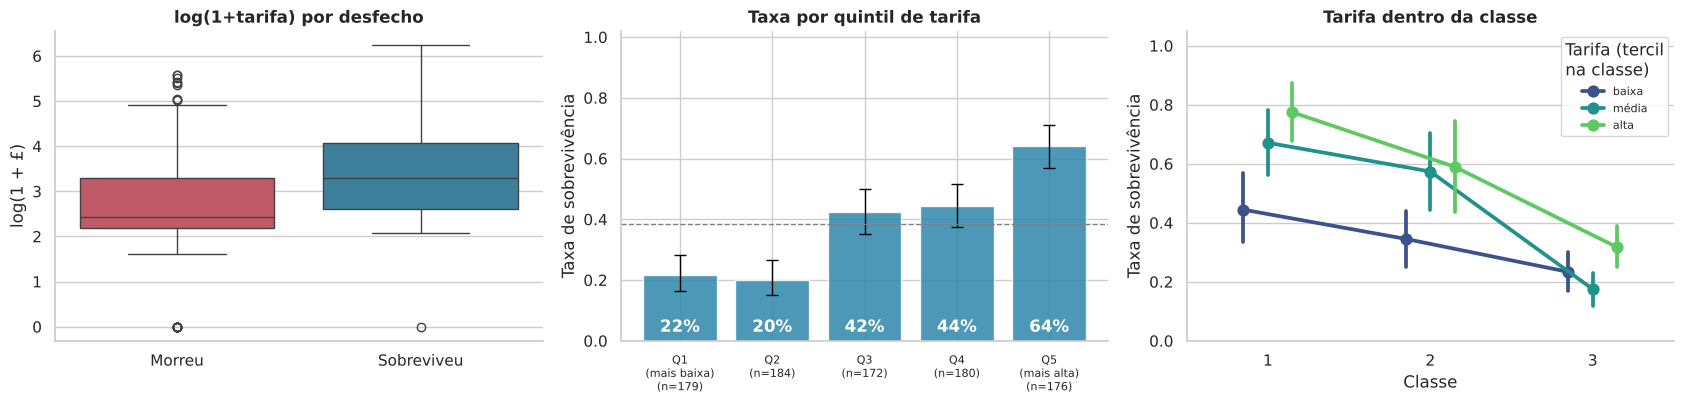

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

# (a) tarifa por desfecho (log)
sns.boxplot(x=df["Survived"].map({0: "Morreu", 1: "Sobreviveu"}), y=np.log1p(df["Fare"]),
            palette=[COR_MORREU, COR_SOBREVIVEU], order=["Morreu", "Sobreviveu"], ax=axes[0])
axes[0].set(title="log(1+tarifa) por desfecho", xlabel="", ylabel="log(1 + £)")

# (b) taxa por quintil de tarifa (usa todos os passageiros)
df["QuintilTarifa"] = pd.qcut(df["Fare"], 5, labels=["Q1\n(mais baixa)", "Q2", "Q3", "Q4", "Q5\n(mais alta)"], duplicates="drop")
plot_taxa(df, "QuintilTarifa", axes[1], "Taxa por quintil de tarifa")
axes[1].tick_params(axis="x", labelsize=8)

# (c) dentro de cada classe, a tarifa ainda importa? (tercis DENTRO da classe)
df["TercilTarifaNaClasse"] = df.groupby("Pclass")["Fare"].transform(lambda s: pd.qcut(s, 3, labels=["baixa", "média", "alta"], duplicates="drop"))
sns.pointplot(data=df, x="Pclass", y="Survived", hue="TercilTarifaNaClasse", hue_order=["baixa", "média", "alta"],
              palette="viridis", dodge=0.3, errorbar=("ci", 95), ax=axes[2])
axes[2].set(title="Tarifa dentro da classe", xlabel="Classe", ylabel="Taxa de sobrevivência", ylim=(0, 1.05))
axes[2].legend(title="Tarifa (tercil\nna classe)", fontsize=8)
plt.tight_layout(); plt.show()

**Leitura:** misturando todos, a taxa sobe de ~22% (quintil mais baixo) a 64% (mais alto). Dentro das classes, o gradiente **persiste na 1ª classe** (44% → 67% → 77% nos tercis de tarifa) e na 2ª (35% → 57% → 59%), mas na 3ª é pequeno e irregular (23%, 18%, 32%). Parte do "efeito da tarifa" é efeito da classe; a parte restante dentro da 1ª/2ª classe provavelmente reflete localização da cabine e tamanho do grupo, o que veremos nos modelos multivariados.

### 4.6 Porto de embarque: efeito real ou confusão?
Se os passageiros de Cherbourg eram mais ricos, o porto estaria apenas "herdando" o efeito da classe.

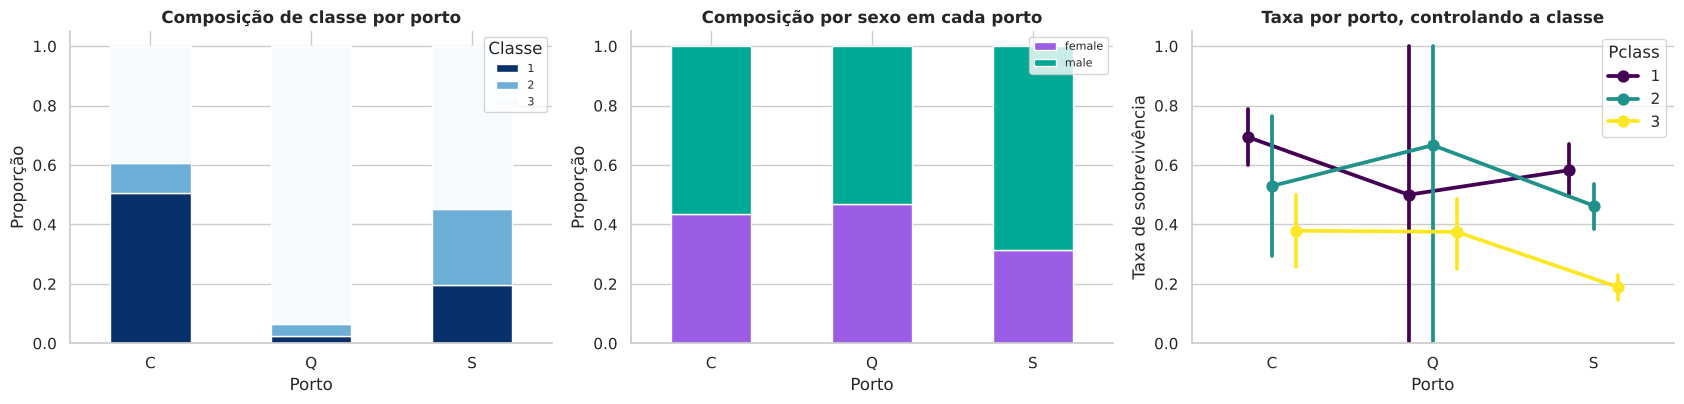

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

# (a) composição de classe em cada porto
comp = pd.crosstab(df["Embarked"], df["Pclass"], normalize="index").loc[["C", "Q", "S"]]
comp.plot(kind="bar", stacked=True, colormap="Blues_r", ax=axes[0], edgecolor="white", rot=0)
axes[0].set(title="Composição de classe por porto", xlabel="Porto", ylabel="Proporção"); axes[0].legend(title="Classe", fontsize=8)

# (b) composição de sexo em cada porto
comp_s = pd.crosstab(df["Embarked"], df["Sex"], normalize="index").loc[["C", "Q", "S"]]
comp_s.plot(kind="bar", stacked=True, color=["#9b5de5", "#00a896"], ax=axes[1], edgecolor="white", rot=0)
axes[1].set(title="Composição por sexo em cada porto", xlabel="Porto", ylabel="Proporção"); axes[1].legend(title="", fontsize=8)

# (c) taxa por porto, SEPARADA por classe
sns.pointplot(data=df, x="Embarked", y="Survived", hue="Pclass", order=["C", "Q", "S"], palette="viridis",
              dodge=0.3, errorbar=("ci", 95), ax=axes[2])
axes[2].set(title="Taxa por porto, controlando a classe", xlabel="Porto", ylabel="Taxa de sobrevivência", ylim=(0, 1.05))
plt.tight_layout(); plt.show()

**Leitura:** 51% dos embarcados em Cherbourg eram de 1ª classe (contra 20% em Southampton), e 94% dos de Queenstown eram de 3ª. Ao separar por classe, a vantagem de Cherbourg **encolhe, mas não desaparece** (1ª classe: 69% vs 58%; 3ª classe: 38% vs 19%). Os grupos de Queenstown em 1ª/2ª classe têm só 2 e 3 pessoas, então esses pontos do gráfico são pouco informativos. Quantificamos a parte que sobra na Parte 7.5.

### 4.7 Tamanho da família

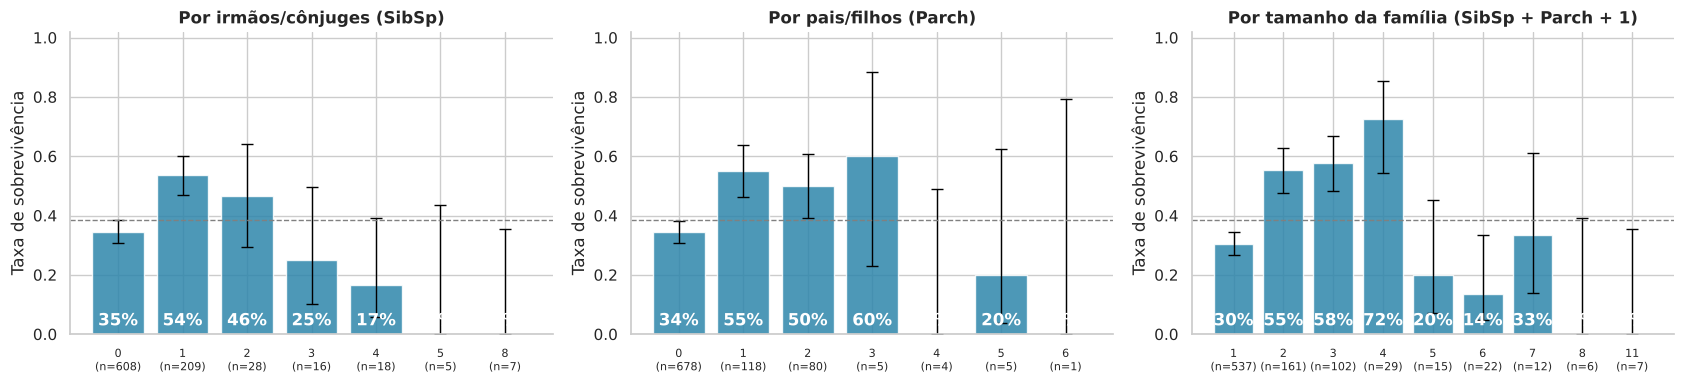

In [18]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1        # +1 = o próprio passageiro
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
plot_taxa(df, "SibSp", axes[0], "Por irmãos/cônjuges (SibSp)")
plot_taxa(df, "Parch", axes[1], "Por pais/filhos (Parch)")
plot_taxa(df, "FamilySize", axes[2], "Por tamanho da família (SibSp + Parch + 1)")
for ax in axes: ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

**Leitura:** há um padrão em "U invertido": quem viajava **sozinho** sobreviveu em 30%, famílias de 2–4 pessoas em 55–72%, e famílias **grandes (≥5)** em apenas 0–33% (agrupadas, 16%). Parte disso se deve à classe (famílias grandes concentram-se na 3ª), mas o modelo ajustado da Parte 7.4 mostra que a penalidade das famílias grandes permanece. Os grupos grandes são poucos, então os intervalos são largos.

## 5. Engenharia de atributos

Criamos variáveis novas a partir das existentes, extraindo informação que está "escondida" em texto e em padrões de preenchimento.

| Nova variável | Como é construída | Por que pode importar |
|---|---|---|
| `Title` / `Title_grp` | título no nome (Mr., Mrs., Miss., Master., ...) | resume sexo, idade e estado civil |
| `FamilySize`, `IsAlone` | SibSp + Parch + 1; 1 se sozinho | proteção ou entrave em uma evacuação |
| `HasCabin`, `Deck` | cabine registrada; 1ª letra da cabine | proxy de posição no navio e de status |
| `TicketGroupSize` | nº de passageiros com o mesmo bilhete | inclui amigos e criados, não só parentes |
| `FarePerPerson` | tarifa ÷ tamanho do grupo de bilhete | o bilhete cobra o grupo todo |
| `Fare_log` | log(1 + tarifa) | reduz a assimetria |

In [19]:
# --- Título ----------------------------------------------------------------
# Os nomes seguem o padrão "Sobrenome, Título. Nomes": pegamos o que está entre a vírgula e o ponto
df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()
print("Títulos encontrados:\n", df["Title"].value_counts().to_dict())

# Agrupamos os raros e unificamos variantes (Mlle→Miss, Mme→Mrs, Ms→Miss)
mapa_titulos = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
                "Mr": "Mr", "Mrs": "Mrs", "Miss": "Miss", "Master": "Master"}
df["Title_grp"] = df["Title"].map(mapa_titulos).fillna("Raro")

# --- Família ---------------------------------------------------------------
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["FamilyCat"] = pd.cut(df["FamilySize"], [0, 1, 4, 20], labels=["Sozinho", "Pequena (2–4)", "Grande (5+)"])

# --- Cabine e convés -----------------------------------------------------------
df["HasCabin"] = df["Cabin"].notna().astype(int)
df["Deck"] = df["Cabin"].str[0].fillna("Desconhecido")

# --- Bilhete: tamanho do grupo que compartilha o mesmo número ----------------------
# (contagem feita nos 891 passageiros; é uma propriedade do bilhete, não usa o desfecho)
df["TicketGroupSize"] = df.groupby("Ticket")["Ticket"].transform("count")
df["FarePerPerson"] = df["Fare"] / df["TicketGroupSize"]
df["Fare_log"] = np.log1p(df["Fare"])

# --- Sobrenome (útil p/ a análise de famílias) -----------------------------------
df["Surname"] = df["Name"].str.split(",").str[0]

df[["Name", "Title", "Title_grp", "FamilySize", "IsAlone", "HasCabin", "Deck", "TicketGroupSize", "FarePerPerson"]].head(6)

Títulos encontrados:
 {'Mr': 517, 'Miss': 182, 'Mrs': 125, 'Master': 40, 'Dr': 7, 'Rev': 6, 'Major': 2, 'Mlle': 2, 'Col': 2, 'Don': 1, 'Mme': 1, 'Ms': 1, 'Lady': 1, 'Sir': 1, 'Capt': 1, 'the Countess': 1, 'Jonkheer': 1}


,Name,Title,Title_grp,FamilySize,IsAlone,HasCabin,Deck,TicketGroupSize,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,Mr,2,0,0,Desconhecido,1,7.2500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,Mrs,2,0,1,C,1,71.2833
2,"Heikkinen, Miss. Laina",Miss,Miss,1,1,0,Desconhecido,1,7.9250
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,Mrs,2,0,1,C,2,26.5500
4,"Allen, Mr. William Henry",Mr,Mr,1,1,0,Desconhecido,1,8.0500
5,"Moran, Mr. James",Mr,Mr,1,1,0,Desconhecido,1,8.4583


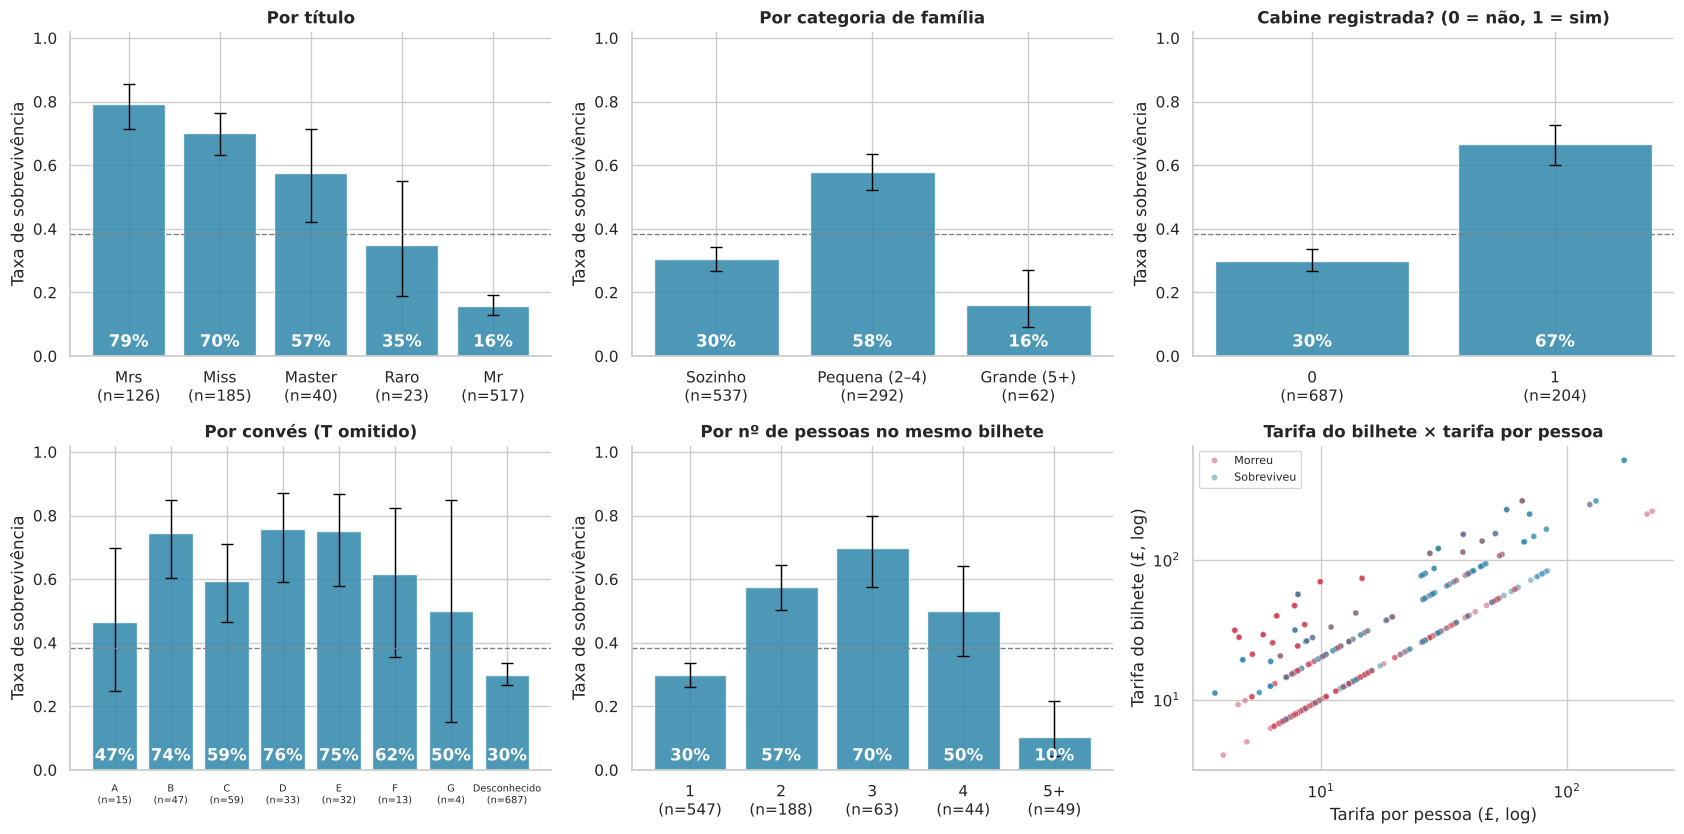

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8.5))
ordem_t = ["Mrs", "Miss", "Master", "Raro", "Mr"]
plot_taxa(df, "Title_grp", axes[0, 0], "Por título", ordem=ordem_t)
plot_taxa(df, "FamilyCat", axes[0, 1], "Por categoria de família")
plot_taxa(df, "HasCabin", axes[0, 2], "Cabine registrada? (0 = não, 1 = sim)")
ordem_deck = ["A", "B", "C", "D", "E", "F", "G", "Desconhecido"]
d_deck = df[df["Deck"].isin(ordem_deck)]
plot_taxa(d_deck, "Deck", axes[1, 0], "Por convés (T omitido)", ordem=[o for o in ordem_deck if o in d_deck["Deck"].unique()])
axes[1, 0].tick_params(axis="x", labelsize=7)
plot_taxa(df.assign(TG=df["TicketGroupSize"].clip(upper=5).astype(int).astype(str).replace("5", "5+")), "TG", axes[1, 1],
          "Por nº de pessoas no mesmo bilhete", ordem=["1", "2", "3", "4", "5+"])
sns.scatterplot(data=df, x="FarePerPerson", y="Fare", hue=df["Survived"].map({0: "Morreu", 1: "Sobreviveu"}),
                palette={"Morreu": COR_MORREU, "Sobreviveu": COR_SOBREVIVEU}, alpha=0.5, s=18, ax=axes[1, 2])
axes[1, 2].set(title="Tarifa do bilhete × tarifa por pessoa", xscale="log", yscale="log", xlabel="Tarifa por pessoa (£, log)", ylabel="Tarifa do bilhete (£, log)")
axes[1, 2].legend(title="", fontsize=8)
plt.tight_layout(); plt.show()

**Leitura:** o **título** é um excelente resumo: "Mrs" (79%), "Miss" (70%) e "Master" (meninos, 58%) sobrevivem muito mais que "Mr" (16%). Ter cabine registrada associa-se a 67% de sobrevivência contra 30% sem registro (convés B, D e E: ~75%). Grupos de bilhete de 2–4 pessoas se saem melhor (50–70%) que viajantes sozinhos (30%), enquanto grupos de 5 ou mais pessoas tiveram apenas 10% (n = 49).

### 5.1 Há "destino compartilhado" dentro de famílias e grupos de bilhete?
Se pessoas que viajam juntas tendem a ter o mesmo desfecho, isso é evidência de que a evacuação foi *coletiva*. Testamos com um **teste de permutação**: comparamos a concordância observada de desfechos dentro dos grupos com a que ocorreria se os desfechos fossem embaralhados ao acaso.

In [21]:
def concordancia_media(survived, grupos):
    """Para cada grupo (>=2 pessoas), fração de pares com o mesmo desfecho; devolve a média ponderada."""
    pares_iguais, pares_total = 0, 0
    for idx in grupos:
        s = survived[idx]
        k, n = s.sum(), len(s)
        total = n * (n - 1) / 2
        iguais = k * (k - 1) / 2 + (n - k) * (n - k - 1) / 2
        pares_iguais += iguais; pares_total += total
    return pares_iguais / pares_total

rng = np.random.default_rng(SEED)
y_arr = df["Survived"].to_numpy()
resultados = {}
for nome, col in [("Mesmo bilhete", "Ticket"), ("Mesmo sobrenome + bilhete", None)]:
    chave = df["Ticket"] if col else df["Surname"] + "|" + df["Ticket"]
    grupos = [np.array(ix) for ix in chave.groupby(chave).indices.values() if len(ix) >= 2]
    obs = concordancia_media(y_arr, grupos)
    nulo = np.array([concordancia_media(rng.permutation(y_arr), grupos) for _ in range(2000)])
    p = (np.sum(nulo >= obs) + 1) / (len(nulo) + 1)
    resultados[nome] = (len(grupos), obs, nulo.mean(), p)

print(f"{'Agrupamento':28s}{'grupos':>8s}{'observado':>11s}{'esperado ao acaso':>20s}{'p (perm.)':>11s}")
for k, (ng, o, e, p) in resultados.items():
    print(f"{k:28s}{ng:8d}{o:11.3f}{e:20.3f}{p:11.4f}")
print("\nInterpretação: concordância observada >> esperada ⇒ quem viajava junto tendia a compartilhar o destino.")

Agrupamento                   grupos  observado   esperado ao acaso  p (perm.)
Mesmo bilhete                    134      0.761               0.525     0.0005
Mesmo sobrenome + bilhete         99      0.783               0.526     0.0005

Interpretação: concordância observada >> esperada ⇒ quem viajava junto tendia a compartilhar o destino.


**Leitura:** em ~76% dos pares que compartilham bilhete o desfecho foi o mesmo, contra ~52,5% esperado ao acaso (p < 0,001). Cuidado: parte dessa concordância é "herdada", porque quem viaja junto também tem o mesmo sexo/classe/idade aproximada, e não prova por si só um mecanismo de decisão coletiva. Mesmo assim, é por isso que `TicketGroupSize` ajuda os modelos.

## 6. Tratamento das idades ausentes (20% dos passageiros)

Uma solução comum é preencher a idade pela média ou mediana geral, ou pela média de cada grupo (Classe × Sexo). Aqui usamos a **mediana por Título × Classe**, que é mais robusta a *outliers* e mais informativa (o título "Master" identifica meninos; "Miss" separa muitas vezes moças de meninas). Também criamos o indicador `Age_ausente`, já que a ausência não é aleatória (Parte 2).

> ⚠️ Na parte de **modelagem**, a imputação será refeita *dentro* do pipeline, aprendida só no conjunto de treino, para evitar vazamento de dados (*data leakage*). Aqui a usamos apenas para análise exploratória e inferência.

Mediana de idade por Título × Classe:


Pclass,1,2,3
Title_grp,,,
Master,4.0,1.0,4.0
Miss,30.0,24.0,18.0
Mr,40.0,31.0,26.0
Mrs,40.0,32.0,31.0
Raro,48.5,46.5,NaN


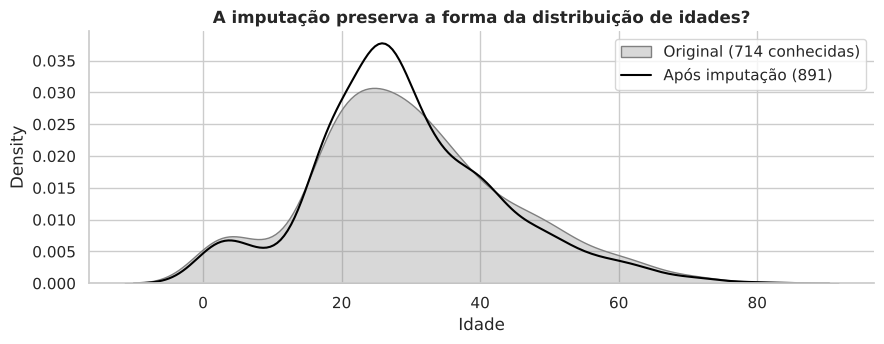

Média antes: 29.70 | depois: 29.14   |   Desvio-padrão antes: 14.53 | depois: 13.49
Nenhum NaN restante em Age_imp? True


In [22]:
# Mediana de idade por Título × Classe (grupos pequenos usam a mediana do título)
med_grupo = df.groupby(["Title_grp", "Pclass"])["Age"].median()
print("Mediana de idade por Título × Classe:")
display(med_grupo.unstack().round(1))

def imputar_idade(linha):
    if pd.notna(linha["Age"]):
        return linha["Age"]
    v = med_grupo.get((linha["Title_grp"], linha["Pclass"]), np.nan)
    return v if pd.notna(v) else df.loc[df["Title_grp"] == linha["Title_grp"], "Age"].median()

df["Age_ausente"] = df["Age"].isna().astype(int)
df["Age_imp"] = df.apply(imputar_idade, axis=1)

fig, ax = plt.subplots(figsize=(9, 3.6))
sns.kdeplot(df["Age"].dropna(), label="Original (714 conhecidas)", fill=True, alpha=0.3, color="gray", ax=ax)
sns.kdeplot(df["Age_imp"], label="Após imputação (891)", color="black", ax=ax)
ax.set(title="A imputação preserva a forma da distribuição de idades?", xlabel="Idade"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Média antes: {df['Age'].mean():.2f} | depois: {df['Age_imp'].mean():.2f}   |   "
      f"Desvio-padrão antes: {df['Age'].std():.2f} | depois: {df['Age_imp'].std():.2f}")
print(f"Nenhum NaN restante em Age_imp? {df['Age_imp'].isna().sum() == 0}")

## 7. Inferência estatística

Até aqui descrevemos. Agora perguntamos: **as diferenças são maiores do que o acaso explicaria? E qual é o efeito de cada fator *mantendo os outros constantes*?**

> 📝 **Nota metodológica.** Um erro comum é aplicar um *teste t* ou uma *ANOVA* sobre a variável binária `Survived`. Isso funciona como aproximação (com n grande), mas o método adequado para comparar proporções entre categorias é o **teste qui-quadrado**, acompanhado de uma medida de tamanho de efeito (**V de Cramér**). Para variáveis contínuas assimétricas (idade, tarifa) usamos o **teste de Mann-Whitney**, que não supõe normalidade.

### 7.1 Associação das variáveis categóricas com a sobrevivência
O *p-valor* diz se a associação é improvável sob independência. O **V de Cramér** (0 a 1) diz o **quão forte** ela é, o que importa mais em amostras grandes, onde quase tudo é "significativo".

,variável,qui²,gl,p-valor,V de Cramér
0,Title_grp,288.1,4,3.96e-61,0.569
1,Sex,263.1,1,3.71e-59,0.543
2,Pclass,102.9,2,4.55e-23,0.340
3,Deck,99.2,8,6.33e-18,0.334
4,HasCabin,89.5,1,3.09e-21,0.317
5,FamilyCat,74.5,2,6.52e-17,0.289
6,IsAlone,36.9,1,1.28e-09,0.203
7,Embarked,26.5,2,1.77e-06,0.173


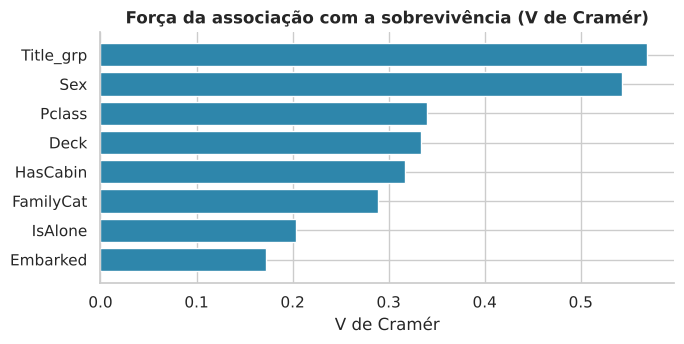

In [23]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, dof, _ = stats.chi2_contingency(ct, correction=False)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
    return chi2, p, dof, v

linhas = []
for col in ["Sex", "Title_grp", "Pclass", "HasCabin", "Deck", "FamilyCat", "IsAlone", "Embarked"]:
    d = df.dropna(subset=[col])
    chi2, p, dof, v = cramers_v(d[col], d["Survived"])
    linhas.append({"variável": col, "qui²": chi2, "gl": dof, "p-valor": p, "V de Cramér": v})
tab_chi = pd.DataFrame(linhas).sort_values("V de Cramér", ascending=False).reset_index(drop=True)
display(tab_chi.style.format({"qui²": "{:.1f}", "p-valor": "{:.2e}", "V de Cramér": "{:.3f}"}).background_gradient(subset=["V de Cramér"], cmap="Blues"))

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(tab_chi["variável"][::-1], tab_chi["V de Cramér"][::-1], color=COR_SOBREVIVEU)
ax.set(title="Força da associação com a sobrevivência (V de Cramér)", xlabel="V de Cramér")
plt.tight_layout(); plt.show()

**Leitura:** todas as associações são estatisticamente significativas, mas a **força** varia: *título* (V = 0,57) e *sexo* (0,54) são fortes; *classe* (0,34), *convés* (0,33; inflado pela categoria "desconhecido", que é quase equivalente a "sem cabine"), *cabine registrada* (0,32) e *categoria de família* (0,29) são moderadas; *viajar só* (0,20) e *porto* (0,17) são fracas. Convenção grosseira: <0,1 desprezível, 0,1–0,3 fraca/moderada, >0,3 forte. Título e sexo são quase redundantes (o título é, em boa parte, o sexo com informação de idade/estado civil).

### 7.2 Quantificando o efeito do sexo: risco relativo e *odds ratio*

In [24]:
# Tabela 2×2: sexo × desfecho
t = pd.crosstab(df["Sex"], df["Survived"]).loc[["female", "male"]]
a, b = t.loc["female", 1], t.loc["female", 0]     # mulheres: sobreviveram / morreram
c, d_ = t.loc["male", 1], t.loc["male", 0]        # homens
p_f, p_m = a / (a + b), c / (c + d_)

rr = p_f / p_m                                    # risco relativo
or_ = (a * d_) / (b * c)                          # odds ratio
ep = np.sqrt(1/a + 1/b + 1/c + 1/d_)              # erro-padrão do log(OR)
ic_or = np.exp(np.log(or_) + np.array([-1.96, 1.96]) * ep)

print(t.rename(columns={0: "Morreu", 1: "Sobreviveu"}).to_string(), "\n")
print(f"P(sobreviver | mulher) = {p_f:.1%}   |   P(sobreviver | homem) = {p_m:.1%}")
print(f"Diferença absoluta     = {100*(p_f-p_m):.1f} pontos percentuais")
print(f"Risco relativo         = {rr:.2f}  (mulheres tinham {rr:.1f}× a chance de sobreviver)")
print(f"Odds ratio             = {or_:.1f}  (IC95%: {ic_or[0]:.1f} – {ic_or[1]:.1f})")

# Teste exato de Fisher para conferir
print("Fisher exato: p =", f"{stats.fisher_exact(t.values)[1]:.2e}")

Survived  Morreu  Sobreviveu
Sex                         
female        81         233
male         468         109 

P(sobreviver | mulher) = 74.2%   |   P(sobreviver | homem) = 18.9%
Diferença absoluta     = 55.3 pontos percentuais
Risco relativo         = 3.93  (mulheres tinham 3.9× a chance de sobreviver)
Odds ratio             = 12.4  (IC95%: 8.9 – 17.1)
Fisher exato: p = 6.46e-60


### 7.3 Variáveis contínuas: idade e tarifa (Mann-Whitney)
Reportamos também a **probabilidade de superioridade** (AUC): a chance de que um sobrevivente sorteado ao acaso tenha valor *maior* que um não sobrevivente sorteado ao acaso (0,5 = sem diferença).

In [25]:
linhas = []
for col, rotulo in [("Age", "Idade (apenas conhecidas)"), ("Age_imp", "Idade (imputada)"),
                    ("Fare", "Tarifa"), ("FarePerPerson", "Tarifa por pessoa"), ("FamilySize", "Tamanho da família")]:
    s1 = df.loc[df["Survived"] == 1, col].dropna()
    s0 = df.loc[df["Survived"] == 0, col].dropna()
    U, p = stats.mannwhitneyu(s1, s0, alternative="two-sided")
    linhas.append({"variável": rotulo, "mediana sobreviventes": s1.median(), "mediana não sobrev.": s0.median(),
                   "U": U, "p-valor": p, "P(superioridade)": U / (len(s1) * len(s0))})
display(pd.DataFrame(linhas).style.format({"mediana sobreviventes": "{:.1f}", "mediana não sobrev.": "{:.1f}", "U": "{:.0f}",
                                         "p-valor": "{:.2e}", "P(superioridade)": "{:.3f}"}))

,variável,mediana sobreviventes,mediana não sobrev.,U,p-valor,P(superioridade)
0,Idade (apenas conhecidas),28.0,28.0,57682,1.60e-01,0.469
1,Idade (imputada),27.5,26.0,89260,2.16e-01,0.475
2,Tarifa,26.0,10.5,129952,4.55e-22,0.692
3,Tarifa por pessoa,13.0,8.1,128928,6.29e-21,0.687
4,Tamanho da família,2.0,1.0,110099,7.97e-07,0.586


**Leitura:** a tarifa distingue sobreviventes de não sobreviventes com probabilidade de superioridade de 0,69 (efeito moderado; p < 10⁻²⁰), parcialmente por refletir a classe. A idade, isoladamente, **não** separa os grupos (0,47; p = 0,16), pois o efeito depende do sexo e da faixa etária (crianças vs. adultos). O tamanho da família tem efeito pequeno (0,59).

### 7.4 Regressão logística: efeitos "mantendo tudo mais constante"
A regressão logística estima, para cada variável, o *odds ratio* **ajustado** pelas demais. Um OR > 1 aumenta a chance de sobreviver; < 1 diminui. Assim separamos o efeito próprio de cada fator.

,OR,IC95% inf,IC95% sup,p-valor
Classe[T.2],0.724,0.315,1.665,0.448
Classe[T.3],0.275,0.110,0.686,0.006
Família[T.Pequena (2–4)],0.953,0.604,1.502,0.835
Família[T.Grande (5+)],0.082,0.030,0.224,0.000
Porto[T.C],1.359,0.838,2.206,0.214
Porto[T.Q],1.209,0.616,2.375,0.581
Mulher (vs homem),14.450,9.622,21.702,0.000
Age10,0.656,0.556,0.775,0.000
Fare_log,1.351,0.966,1.891,0.079
HasCabin,2.234,1.137,4.389,0.020


n = 889  |  pseudo-R² de McFadden = 0.364


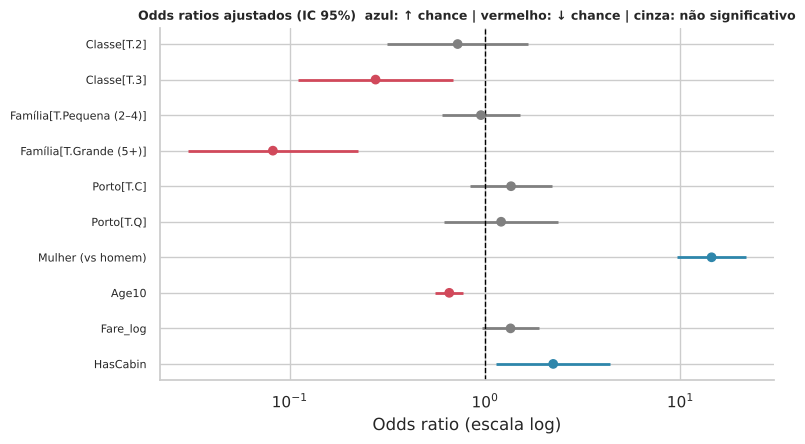

In [26]:
df["Mulher"] = (df["Sex"] == "female").astype(int)
df["Age10"] = df["Age_imp"] / 10                      # efeito por década de idade

formula_cheia = ("Survived ~ Mulher + C(Pclass) + Age10 + C(FamilyCat, Treatment('Sozinho')) "
                 "+ Fare_log + HasCabin + C(Embarked, Treatment('S'))")
m_cheio = smf.logit(formula_cheia, data=df).fit(disp=0)

def tabela_or(modelo):
    ci = modelo.conf_int()
    t = pd.DataFrame({"OR": np.exp(modelo.params), "IC95% inf": np.exp(ci[0]), "IC95% sup": np.exp(ci[1]), "p-valor": modelo.pvalues})
    return t.drop(index="Intercept")

t_or = tabela_or(m_cheio)
t_or.index = (t_or.index.str.replace(r"C\(FamilyCat, Treatment\('Sozinho'\)\)", "Família", regex=True)
                         .str.replace(r"C\(Embarked, Treatment\('S'\)\)", "Porto", regex=True)
                         .str.replace(r"C\(Pclass\)", "Classe", regex=True).str.replace("Mulher", "Mulher (vs homem)"))
display(t_or.round(3))
print(f"n = {int(m_cheio.nobs)}  |  pseudo-R² de McFadden = {m_cheio.prsquared:.3f}")

# Gráfico de floresta (forest plot) em escala log
fig, ax = plt.subplots(figsize=(8, 4.6))
yy = np.arange(len(t_or))[::-1]
cores = [COR_SOBREVIVEU if (lo > 1) else COR_MORREU if (hi < 1) else "gray" for lo, hi in zip(t_or["IC95% inf"], t_or["IC95% sup"])]
ax.hlines(yy, t_or["IC95% inf"], t_or["IC95% sup"], color=cores, lw=2)
ax.scatter(t_or["OR"], yy, color=cores, zorder=3)
ax.axvline(1, color="black", ls="--", lw=1)
ax.set_xscale("log"); ax.set_yticks(yy); ax.set_yticklabels(t_or.index, fontsize=8)
ax.set(title="Odds ratios ajustados (IC 95%)  azul: ↑ chance | vermelho: ↓ chance | cinza: não significativo", xlabel="Odds ratio (escala log)")
ax.title.set_fontsize(9)
plt.tight_layout(); plt.show()

**Leitura:** com tudo mais constante, **ser mulher** multiplica as *odds* de sobreviver por ~14 (OR 14,5; IC 9,6–21,7); **estar na 3ª classe** (vs. 1ª) reduz as *odds* em ~72% (OR 0,28), enquanto a 2ª classe não se distingue estatisticamente da 1ª; **cada década a mais de idade** reduz as *odds* em ~34% (OR 0,66); **famílias grandes (5+)** têm OR 0,08 em relação a quem viaja só; e **ter cabine registrada** dobra as *odds* (OR 2,2). Já o **porto** (p = 0,21 e 0,58) e a **tarifa** (p = 0,08) **não são significativos no modelo completo**: seus efeitos brutos foram absorvidos por classe, sexo, cabine e tamanho do grupo. Famílias pequenas (2–4) não diferem de quem viaja só *depois* desses controles, embora a taxa bruta seja o dobro.

(*Odds* não são probabilidades: um OR de 14 não significa 14× a probabilidade; para isso veja as probabilidades previstas na Parte 7.6.)

### 7.5 O porto de embarque tem efeito próprio? (teste de razão de verossimilhança)
Comparamos modelos com e sem a variável, na mesma amostra, para testar formalmente se o porto acrescenta algo depois de controlar classe e sexo.

In [27]:
d_emb = df.dropna(subset=["Embarked"])
m_sem_ctrl = smf.logit("Survived ~ C(Embarked, Treatment('S'))", data=d_emb).fit(disp=0)
m_com = smf.logit("Survived ~ C(Embarked, Treatment('S')) + C(Pclass) + Mulher", data=d_emb).fit(disp=0)
m_sem = smf.logit("Survived ~ C(Pclass) + Mulher", data=d_emb).fit(disp=0)

print("PORTO SOZINHO (OR vs Southampton):")
print(tabela_or(m_sem_ctrl).round(3).to_string(), "\n")
print("PORTO CONTROLANDO CLASSE E SEXO (OR vs Southampton):")
print(tabela_or(m_com).loc[[i for i in tabela_or(m_com).index if "Embarked" in i]].round(3).to_string(), "\n")

lr = 2 * (m_com.llf - m_sem.llf)
p_lr = stats.chi2.sf(lr, df=2)
print(f"Teste de razão de verossimilhança (porto, após classe e sexo): χ²(2) = {lr:.2f}, p = {p_lr:.3f}")

PORTO SOZINHO (OR vs Southampton):
                                     OR  IC95% inf  IC95% sup  p-valor
C(Embarked, Treatment('S'))[T.C]  2.440      1.728      3.446    0.000
C(Embarked, Treatment('S'))[T.Q]  1.256      0.772      2.043    0.358 

PORTO CONTROLANDO CLASSE E SEXO (OR vs Southampton):
                                     OR  IC95% inf  IC95% sup  p-valor
C(Embarked, Treatment('S'))[T.C]  1.814      1.160      2.835    0.009
C(Embarked, Treatment('S'))[T.Q]  1.568      0.845      2.911    0.154 

Teste de razão de verossimilhança (porto, após classe e sexo): χ²(2) = 7.96, p = 0.019


**Leitura:** o OR bruto de Cherbourg (vs. Southampton) é 2,44; controlando **classe e sexo** cai para 1,81 (e o teste de razão de verossimilhança ainda indica efeito residual, p ≈ 0,02); no modelo completo da Parte 7.4 (que inclui cabine, família etc.) cai para ~1,36 e deixa de ser significativo. Conclusão cautelosa: **a maior parte da vantagem de Cherbourg é composição (classe, cabine), restando no máximo um efeito pequeno**, difícil de separar com 889 observações.

### 7.6 Interações: o efeito de ser mulher depende da classe? E da idade?
Se sim, um modelo puramente aditivo deixa informação de lado.

In [28]:
m_aditivo = smf.logit("Survived ~ Mulher + C(Pclass) + Age10", data=df).fit(disp=0)
m_int_cls = smf.logit("Survived ~ Mulher * C(Pclass) + Age10", data=df).fit(disp=0)
m_int_idade = smf.logit("Survived ~ Mulher * C(Pclass) + Mulher * Age10", data=df).fit(disp=0)

for nome, m_novo, m_base, gl in [("Sexo × Classe", m_int_cls, m_aditivo, 2), ("Sexo × Idade (além de Sexo × Classe)", m_int_idade, m_int_cls, 1)]:
    lr = 2 * (m_novo.llf - m_base.llf)
    print(f"{nome:40s} LR χ²({gl}) = {lr:6.2f}   p = {stats.chi2.sf(lr, gl):.4g}")
print(f"\nAIC  aditivo: {m_aditivo.aic:.1f} | + Sexo×Classe: {m_int_cls.aic:.1f} | + Sexo×Idade: {m_int_idade.aic:.1f}  (menor = melhor)")

# Probabilidades previstas pelo modelo com interações, por perfil
grade = pd.DataFrame([(m, c, 30/10) for m in (0, 1) for c in (1, 2, 3)], columns=["Mulher", "Pclass", "Age10"])
grade["P(sobreviver) aos 30 anos"] = m_int_idade.predict(grade).round(3)
display(grade.assign(Perfil=grade["Mulher"].map({1: "Mulher", 0: "Homem"}) + ", classe " + grade["Pclass"].astype(str))[["Perfil", "P(sobreviver) aos 30 anos"]])

Sexo × Classe                            LR χ²(2) =  32.71   p = 7.905e-08
Sexo × Idade (além de Sexo × Classe)     LR χ²(1) =   3.50   p = 0.06144

AIC  aditivo: 810.1 | + Sexo×Classe: 781.4 | + Sexo×Idade: 779.9  (menor = melhor)


,Perfil,P(sobreviver) aos 30 anos
0,"Homem, classe 1",0.500
1,"Homem, classe 2",0.140
2,"Homem, classe 3",0.102
3,"Mulher, classe 1",0.972
4,"Mulher, classe 2",0.921
5,"Mulher, classe 3",0.453


**Leitura:** a interação **Sexo × Classe é altamente significativa** (p ≈ 8×10⁻⁸) e reduz o AIC em ~29 pontos: o modelo aditivo é inadequado. A interação Sexo × Idade é só marginal (p ≈ 0,06). Pelo modelo, aos 30 anos a probabilidade prevista é de 97% (mulher, 1ª), 92% (2ª) e 45% (3ª), contra 50% (homem, 1ª), 14% (2ª) e 10% (3ª). **Uma mulher de 3ª classe teve chance inferior à de um homem de 1ª classe.**

## 8. Correlações, multicolinearidade e informação mútua

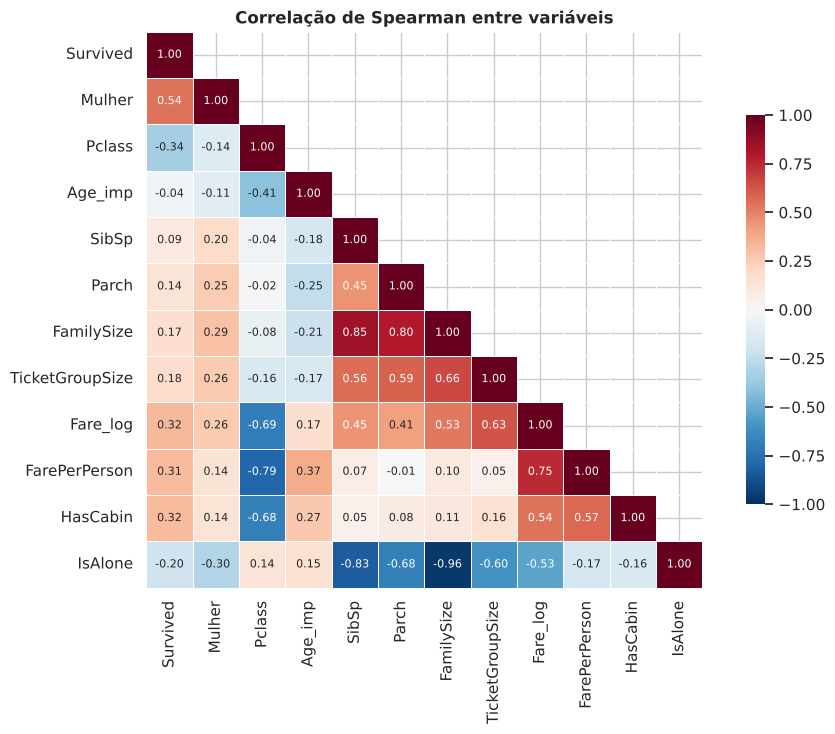

Correlação de cada variável com a sobrevivência (Spearman):
Mulher             0.543
Pclass            -0.340
Fare_log           0.324
HasCabin           0.317
FarePerPerson      0.315
IsAlone           -0.203
TicketGroupSize    0.181
FamilySize         0.165
Parch              0.138
SibSp              0.089
Age_imp           -0.041


In [29]:
# 8.1 Matriz de correlação de Spearman (robusta a assimetria; funciona com binárias/ordinais)
cols_corr = ["Survived", "Mulher", "Pclass", "Age_imp", "SibSp", "Parch", "FamilySize", "TicketGroupSize",
             "Fare_log", "FarePerPerson", "HasCabin", "IsAlone"]
corr = df[cols_corr].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.7}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Correlação de Spearman entre variáveis")
plt.tight_layout(); plt.show()
print("Correlação de cada variável com a sobrevivência (Spearman):")
print(corr["Survived"].drop("Survived").sort_values(key=abs, ascending=False).round(3).to_string())

**Leitura:** a variável mais correlacionada com a sobrevivência é o sexo feminino (ρ = 0,54), seguida de classe (−0,34), tarifa (0,32) e cabine registrada (0,32). A idade tem correlação praticamente nula (−0,04), o que **não** significa que seja irrelevante: seu efeito é não linear e depende do sexo e da faixa etária. Tarifa, classe e cabine são fortemente inter-relacionadas (veja o triângulo inferior), o que explica por que seus efeitos "individuais" encolhem nos modelos ajustados.

In [30]:
# 8.2 Multicolinearidade: Fator de Inflação da Variância (VIF). Regra prática: VIF > 5–10 é preocupante
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings as _w
_w.simplefilter('ignore')      # silencia avisos de matriz singular do caso redundante abaixo
Xv = sm.add_constant(df[["Mulher", "Pclass", "Age_imp", "FamilySize", "Fare_log", "HasCabin"]])
vif = pd.Series([variance_inflation_factor(Xv.values, i) for i in range(1, Xv.shape[1])], index=Xv.columns[1:])
print("VIF (conjunto do modelo logístico):"); print(vif.round(2).to_string())

Xv2 = sm.add_constant(df[["Mulher", "Pclass", "Age_imp", "SibSp", "Parch", "FamilySize", "Fare_log"]])
vif2 = pd.Series([variance_inflation_factor(Xv2.values, i) for i in range(1, Xv2.shape[1])], index=Xv2.columns[1:])
print("\nVIF incluindo SibSp, Parch e FamilySize juntos (FamilySize = SibSp + Parch + 1 → colinearidade perfeita):"); print(vif2.clip(upper=1000).round(1).to_string(), "\n(valores truncados em 1000; na prática, VIF = ∞)")
print("\n→ Moral: nunca use SibSp, Parch e FamilySize simultaneamente em modelos lineares/logísticos sem regularização.")

VIF (conjunto do modelo logístico):
Mulher        1.10
Pclass        3.37
Age_imp       1.33
FamilySize    1.56
Fare_log      2.75
HasCabin      2.17

VIF incluindo SibSp, Parch e FamilySize juntos (FamilySize = SibSp + Parch + 1 → colinearidade perfeita):
Mulher           1.1
Pclass           2.5
Age_imp          1.3
SibSp         1000.0
Parch         1000.0
FamilySize    1000.0
Fare_log         2.7 
(valores truncados em 1000; na prática, VIF = ∞)

→ Moral: nunca use SibSp, Parch e FamilySize simultaneamente em modelos lineares/logísticos sem regularização.


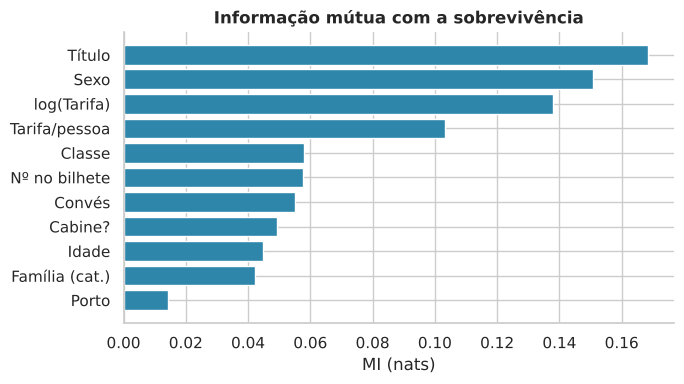

In [31]:
# 8.3 Informação mútua: captura relações não lineares e interações simples
aux = pd.DataFrame({
    "Sexo": df["Mulher"], "Classe": df["Pclass"], "Título": df["Title_grp"].astype("category").cat.codes,
    "Convés": df["Deck"].astype("category").cat.codes, "Cabine?": df["HasCabin"],
    "Porto": df["Embarked"].fillna("S").astype("category").cat.codes, "Família (cat.)": df["FamilyCat"].astype(str).astype("category").cat.codes,
    "Nº no bilhete": df["TicketGroupSize"], "Idade": df["Age_imp"], "log(Tarifa)": df["Fare_log"], "Tarifa/pessoa": df["FarePerPerson"],
})
discretas = [c not in ("Idade", "log(Tarifa)", "Tarifa/pessoa") for c in aux.columns]
mi = pd.Series(mutual_info_classif(aux, df["Survived"], discrete_features=discretas, random_state=SEED), index=aux.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(mi.index, mi.values, color=COR_SOBREVIVEU)
ax.set(title="Informação mútua com a sobrevivência", xlabel="MI (nats)")
plt.tight_layout(); plt.show()

**Leitura:** pela informação mútua (que capta relações não lineares), sexo e título ficam no topo, seguidos de classe e tarifa. Atenção: a MI da tarifa e da idade (contínuas) é estimada por vizinhos mais próximos e é mais ruidosa.

## 9. Modelagem preditiva

### Protocolo (para uma avaliação honesta)
1. **Separar um conjunto de teste (20%) e não tocá-lo** até o final.
2. Todo o pré-processamento (imputação de idade, padronização, one-hot) fica **dentro de um `Pipeline`**, aprendido apenas com os dados de treino de cada *fold*. Isso evita **vazamento de dados**.
3. Comparar modelos por **validação cruzada repetida** (5 folds × 3 repetições) no treino.
4. Ajustar hiperparâmetros por *grid search* (métrica: AUC-ROC) só no treino.
5. Avaliar **uma vez** no teste.
6. Comparar contra **linhas de base simples** (sempre "morreu"; "mulher sobrevive, homem morre"), pois sem elas a acurácia não tem contexto.

> Ordem de grandeza para comparação: modelos honestos no desafio do Kaggle costumam ficar na faixa de 77–80% de acurácia no *leaderboard* público; aqui, com validação cruzada, esperamos algo em torno de 80–83%.

In [32]:
# --- Transformador próprio: imputa Age pela mediana de (Título × Classe) aprendida SÓ no treino ------
class ImputadorIdade(BaseEstimator, TransformerMixin):
    """Preenche Age com a mediana do grupo (Title_grp, Pclass) e cria o indicador Age_ausente."""
    def fit(self, X, y=None):
        self.med_grupo_ = X.groupby(["Title_grp", "Pclass"])["Age"].median()
        self.med_titulo_ = X.groupby("Title_grp")["Age"].median()
        self.med_geral_ = X["Age"].median()
        return self
    def transform(self, X):
        X = X.copy()
        X["Age_ausente"] = X["Age"].isna().astype(int)
        chaves = pd.MultiIndex.from_frame(X[["Title_grp", "Pclass"]])
        alvo = pd.Series(self.med_grupo_.reindex(chaves).values, index=X.index)
        alvo = alvo.fillna(X["Title_grp"].map(self.med_titulo_)).fillna(self.med_geral_)
        X["Age"] = X["Age"].fillna(alvo)
        return X

COLS_NUM = ["Age", "SibSp", "Parch", "Fare_log", "FamilySize", "TicketGroupSize", "Age_ausente"]
COLS_CAT = ["Pclass", "Sex", "Embarked", "Title_grp", "HasCabin", "IsAlone"]

def monta_pipeline(modelo):
    pre = ColumnTransformer([
        ("num", StandardScaler(), COLS_NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), COLS_CAT),
    ])
    return Pipeline([("idade", ImputadorIdade()), ("pre", pre), ("modelo", modelo)])

# Matriz de atributos (Age mantém NaN de propósito: quem imputa é o pipeline)
X = df[["Age", "SibSp", "Parch", "Fare_log", "FamilySize", "TicketGroupSize",
        "Pclass", "Sex", "Embarked", "Title_grp", "HasCabin", "IsAlone"]].copy()
for c in ["Pclass", "HasCabin", "IsAlone"]:
    X[c] = X[c].astype(str)            # tratados como categorias, não como números
y = df["Survived"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Treino: {X_tr.shape[0]} | Teste: {X_te.shape[0]} | taxa de sobrev. treino {y_tr.mean():.3f} / teste {y_te.mean():.3f}")

Treino: 712 | Teste: 179 | taxa de sobrev. treino 0.383 / teste 0.385


### 9.1 Linhas de base e comparação de modelos por validação cruzada

Referência: a regra 'mulher vive, homem morre' acerta 0.789 do conjunto de treino (sem ajuste algum).



,acurácia,± dp,AUC-ROC,F1
modelo,,,,
Dummy (maioria),0.617000,0.003000,0.500000,0.000000
Regressão Logística,0.827000,0.026000,0.871000,0.770000
KNN (k=15),0.811000,0.024000,0.865000,0.735000
SVM (RBF),0.832000,0.024000,0.865000,0.771000
Random Forest,0.817000,0.025000,0.874000,0.758000
Gradient Boosting,0.830000,0.027000,0.893000,0.768000


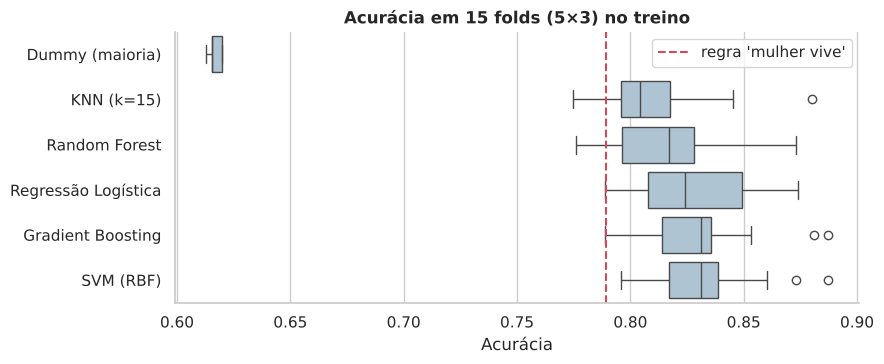

In [33]:
modelos = {
    "Dummy (maioria)": DummyClassifier(strategy="most_frequent"),
    "Regressão Logística": LogisticRegression(max_iter=2000),
    "KNN (k=15)": KNeighborsClassifier(n_neighbors=15),
    "SVM (RBF)": SVC(probability=True, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=SEED),
}
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
scoring = {"acc": "accuracy", "auc": "roc_auc", "f1": "f1"}

res_cv, folds_acc = [], {}
for nome, m in modelos.items():
    r = cross_validate(monta_pipeline(m), X_tr, y_tr, cv=cv_rep, scoring=scoring, n_jobs=-1)
    folds_acc[nome] = r["test_acc"]
    res_cv.append({"modelo": nome, "acurácia": r["test_acc"].mean(), "± dp": r["test_acc"].std(),
                   "AUC-ROC": r["test_auc"].mean(), "F1": r["test_f1"].mean()})
tab_cv = pd.DataFrame(res_cv).set_index("modelo")
acc_regra_treino = ((X_tr["Sex"] == "female").astype(int) == y_tr).mean()
print(f"Referência: a regra 'mulher vive, homem morre' acerta {acc_regra_treino:.3f} do conjunto de treino (sem ajuste algum).\n")
display(tab_cv.round(3).style.background_gradient(subset=["acurácia", "AUC-ROC"], cmap="Blues"))

fig, ax = plt.subplots(figsize=(9, 3.8))
ordem_m = tab_cv["acurácia"].sort_values().index
sns.boxplot(data=pd.DataFrame(folds_acc)[ordem_m], orient="h", color="#a9c5d8", ax=ax)
ax.set(title="Acurácia em 15 folds (5×3) no treino", xlabel="Acurácia")
ax.axvline(acc_regra_treino, color=COR_MORREU, ls="--", label="regra 'mulher vive'"); ax.legend()
plt.tight_layout(); plt.show()

**Leitura:** todos os modelos reais ficam entre 81% e 83% de acurácia (desvio-padrão entre folds ≈ 2,5 p.p.), ou seja, **estatisticamente empatados**, e só ~2–5 p.p. acima da regra de uma linha (≈ 79%). O AUC é um pouco melhor para o Gradient Boosting (0,89), a menor diferença entre modelos que vale a pena notar.

### 9.2 Ajuste de hiperparâmetros (*grid search*)
Usamos validação cruzada de 5 folds dentro do treino e escolhemos pelo **AUC-ROC**, métrica que não depende de um limiar de decisão.

In [34]:
grades = {
    "Regressão Logística": {"modelo__C": [0.03, 0.1, 0.3, 1, 3, 10]},
    "KNN (k=15)": {"modelo__n_neighbors": [7, 11, 15, 25, 35]},
    "SVM (RBF)": {"modelo__C": [0.5, 1, 3, 10], "modelo__gamma": ["scale", 0.01, 0.03, 0.1]},
    "Random Forest": {"modelo__max_depth": [3, 5, 8, None], "modelo__min_samples_leaf": [1, 3, 5]},
    "Gradient Boosting": {"modelo__n_estimators": [100, 200], "modelo__learning_rate": [0.03, 0.1], "modelo__max_depth": [2, 3]},
}
cv_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
tunados = {}
for nome, g in grades.items():
    gs = GridSearchCV(monta_pipeline(modelos[nome]), g, scoring="roc_auc", cv=cv_grid, n_jobs=-1)
    gs.fit(X_tr, y_tr)
    tunados[nome] = gs
    print(f"{nome:22s} AUC (CV) = {gs.best_score_:.4f}  | melhores parâmetros: { {k.split('__')[1]: v for k, v in gs.best_params_.items()} }")

nome_melhor = max(tunados, key=lambda k: tunados[k].best_score_)     # escolha feita SEM olhar o teste
print(f"\n🏆 Melhor modelo pela validação cruzada: {nome_melhor}")

Regressão Logística    AUC (CV) = 0.8706  | melhores parâmetros: {'C': 1}


KNN (k=15)             AUC (CV) = 0.8722  | melhores parâmetros: {'n_neighbors': 25}


SVM (RBF)              AUC (CV) = 0.8731  | melhores parâmetros: {'C': 10, 'gamma': 0.03}


Random Forest          AUC (CV) = 0.8864  | melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 3}


Gradient Boosting      AUC (CV) = 0.9003  | melhores parâmetros: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}

🏆 Melhor modelo pela validação cruzada: Gradient Boosting


### 9.3 Avaliação final no conjunto de teste (uma única vez)
Incluímos duas linhas de base: **"sempre morre"** e a **regra de uma linha** *"mulher sobrevive, homem morre"*. Qualquer modelo útil precisa superá-las com folga.

In [35]:
def metricas(y_true, prob, limiar=0.5):
    pred = (prob >= limiar).astype(int)
    return {"acurácia": accuracy_score(y_true, pred), "precisão": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred), "F1": f1_score(y_true, pred), "AUC-ROC": roc_auc_score(y_true, prob),
            "Brier": brier_score_loss(y_true, prob)}

linhas = {}
linhas["Base: sempre 'morreu'"] = metricas(y_te, np.zeros(len(y_te)))
linhas["Base: regra 'mulher vive'"] = metricas(y_te, (X_te["Sex"] == "female").astype(float).values)
probas_te = {}
for nome, gs in tunados.items():
    probas_te[nome] = gs.predict_proba(X_te)[:, 1]
    linhas[nome] = metricas(y_te, probas_te[nome])
tab_te = pd.DataFrame(linhas).T
# IC95% de Wilson para a acurácia (n = 179 → incerteza grande!)
ic = tab_te["acurácia"].apply(lambda a: wilson(round(a * len(y_te)), len(y_te)))
tab_te["IC95% acurácia"] = ic.apply(lambda t: f"{t[0]:.3f} – {t[1]:.3f}")
display(tab_te.round(3).style.background_gradient(subset=["acurácia", "AUC-ROC"], cmap="Blues"))
print(f"⚠️ Com apenas {len(y_te)} passageiros no teste, 1 acerto a mais ou a menos muda a acurácia em {100/len(y_te):.2f} p.p. "
      f"Diferenças menores que ~5 p.p. entre modelos NÃO são estatisticamente distinguíveis.")

,acurácia,precisão,recall,F1,AUC-ROC,Brier,IC95% acurácia
Base: sempre 'morreu',0.615000,0.000000,0.000000,0.000000,0.500000,0.385000,0.542 – 0.683
Base: regra 'mulher vive',0.777000,0.738000,0.652000,0.692000,0.753000,0.223000,0.710 – 0.831
Regressão Logística,0.844000,0.806000,0.783000,0.794000,0.868000,0.130000,0.783 – 0.890
KNN (k=15),0.793000,0.750000,0.696000,0.722000,0.845000,0.147000,0.728 – 0.846
SVM (RBF),0.816000,0.800000,0.696000,0.744000,0.873000,0.136000,0.752 – 0.866
Random Forest,0.810000,0.787000,0.696000,0.738000,0.849000,0.139000,0.746 – 0.861
Gradient Boosting,0.804000,0.766000,0.710000,0.737000,0.830000,0.152000,0.740 – 0.856


⚠️ Com apenas 179 passageiros no teste, 1 acerto a mais ou a menos muda a acurácia em 0.56 p.p. Diferenças menores que ~5 p.p. entre modelos NÃO são estatisticamente distinguíveis.


Gradient Boosting     : acerta e a regra erra = 16 | erra e a regra acerta = 11 | p (McNemar exato) = 0.442
Regressão Logística   : acerta e a regra erra = 15 | erra e a regra acerta =  3 | p (McNemar exato) = 0.008


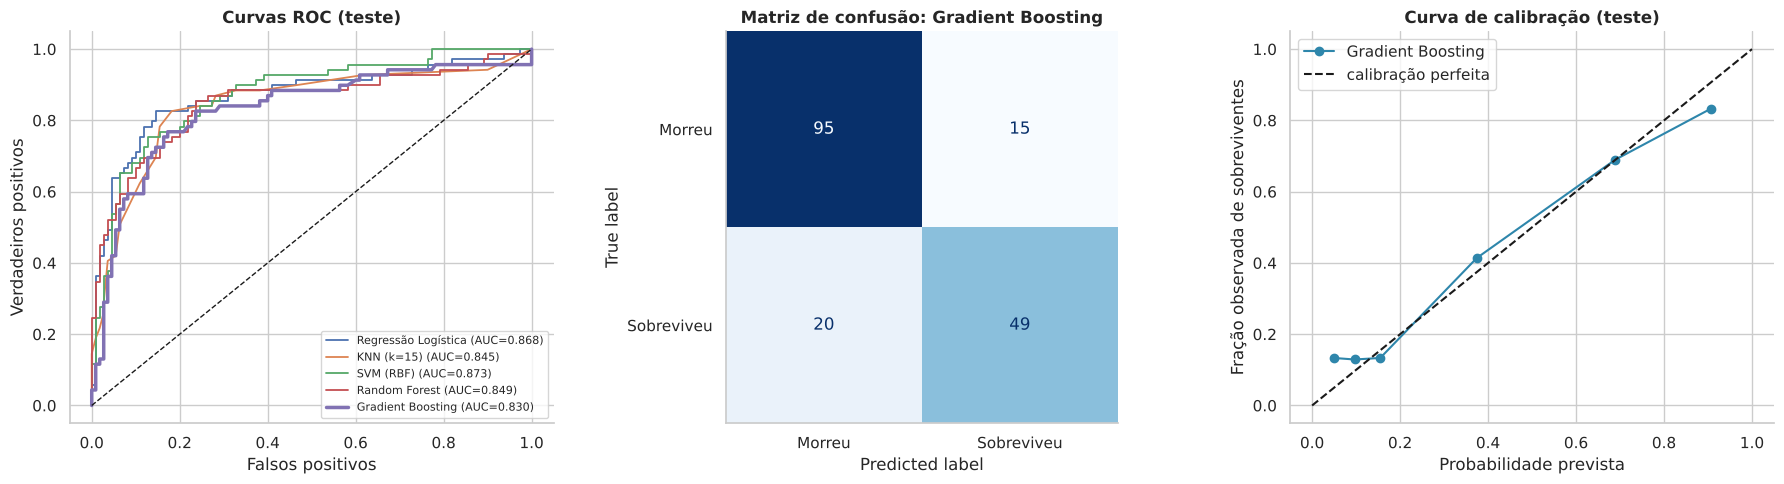

              precision    recall  f1-score   support

      Morreu      0.826     0.864     0.844       110
  Sobreviveu      0.766     0.710     0.737        69

    accuracy                          0.804       179
   macro avg      0.796     0.787     0.791       179
weighted avg      0.803     0.804     0.803       179



In [36]:
# O modelo escolhido é realmente melhor que a regra de uma linha? Teste exato nos pares discordantes (McNemar exato)
from scipy.stats import binomtest
regra = (X_te["Sex"] == "female").astype(int).values
for nome in [nome_melhor, "Regressão Logística"]:
    pm = (probas_te[nome] >= 0.5).astype(int); yt = y_te.values
    so_modelo = int(((pm == yt) & (regra != yt)).sum()); so_regra = int(((pm != yt) & (regra == yt)).sum())
    print(f"{nome:22s}: acerta e a regra erra = {so_modelo:2d} | erra e a regra acerta = {so_regra:2d} | p (McNemar exato) = {binomtest(so_modelo, so_modelo + so_regra).pvalue:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Curvas ROC
for nome, pr in probas_te.items():
    fpr, tpr, _ = roc_curve(y_te, pr)
    axes[0].plot(fpr, tpr, lw=2.5 if nome == nome_melhor else 1.3, label=f"{nome} (AUC={roc_auc_score(y_te, pr):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(title="Curvas ROC (teste)", xlabel="Falsos positivos", ylabel="Verdadeiros positivos"); axes[0].legend(fontsize=8, loc="lower right")

# (b) Matriz de confusão do melhor modelo
pred_melhor = (probas_te[nome_melhor] >= 0.5).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_te, pred_melhor), display_labels=["Morreu", "Sobreviveu"]).plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title(f"Matriz de confusão: {nome_melhor}"); axes[1].grid(False)

# (c) Calibração: quando o modelo diz "70%", ~70% sobrevivem?
fp, mp = calibration_curve(y_te, probas_te[nome_melhor], n_bins=6, strategy="quantile")
axes[2].plot(mp, fp, "o-", color=COR_SOBREVIVEU, label=nome_melhor); axes[2].plot([0, 1], [0, 1], "k--", label="calibração perfeita")
axes[2].set(title="Curva de calibração (teste)", xlabel="Probabilidade prevista", ylabel="Fração observada de sobreviventes"); axes[2].legend()
plt.tight_layout(); plt.show()
print(classification_report(y_te, pred_melhor, target_names=["Morreu", "Sobreviveu"], digits=3))

**Leitura honesta dos resultados de teste:**
* O modelo escolhido pela validação cruzada (Gradient Boosting) obteve 80,4% de acurácia no teste; a regressão logística, 84,4%. **Isso não significa que a logística seja "melhor"**: com n = 179, o intervalo de 95% da acurácia tem ±6 p.p., e na validação cruzada (muito mais dados) os dois ficaram empatados (83%). Não trocamos de modelo depois de ver o teste, pois isso o contaminaria.
* Todos os modelos superam a regra de uma linha (77,7% no teste) por 1,6 a 6,7 p.p., mas, no teste de McNemar, a diferença do modelo escolhido para a regra **não é estatisticamente significativa** (p ≈ 0,44). Com 179 passageiros não há poder para distinguir.
* Como o teste é pequeno, é prudente focar na validação cruzada (muito mais dados) e na comparação com as linhas de base. O que ganhamos com o protocolo é **rigor** (pipeline sem vazamento, validação repetida, intervalos de confiança) e **interpretabilidade**. Com estes dados a acurácia parece ter um teto perto de 82–85%.
* O modelo erra mais ao prever sobreviventes: o recall da classe "Sobreviveu" fica perto de 70%.

## 10. Diagnóstico do modelo: o que ele aprendeu e onde erra
### 10.1 Importância por permutação
Embaralhamos uma variável por vez no conjunto de teste e medimos quanto o AUC cai. Quanto maior a queda, mais o modelo depende dela. (Funciona com qualquer modelo e usa as variáveis originais, antes do one-hot.)

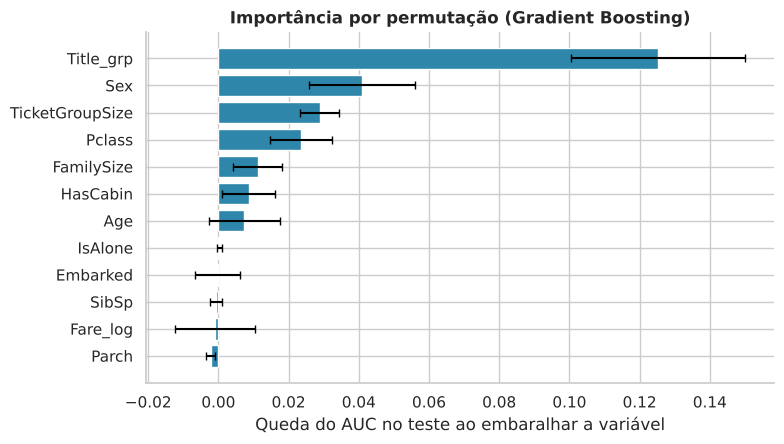

In [37]:
melhor = tunados[nome_melhor].best_estimator_
imp = permutation_importance(melhor, X_te, y_te, scoring="roc_auc", n_repeats=50, random_state=SEED, n_jobs=-1)
imp_df = pd.DataFrame({"var": X_te.columns, "queda_AUC": imp.importances_mean, "dp": imp.importances_std}).sort_values("queda_AUC")
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.barh(imp_df["var"], imp_df["queda_AUC"], xerr=imp_df["dp"], color=COR_SOBREVIVEU, ecolor="black", capsize=3)
ax.set(title=f"Importância por permutação ({nome_melhor})", xlabel="Queda do AUC no teste ao embaralhar a variável")
plt.tight_layout(); plt.show()

**Leitura:** o **título** é de longe a variável mais importante (queda de ~0,13 no AUC), seguido de sexo, tamanho do grupo de bilhete e classe. Tarifa, porto, SibSp e Parch têm importância ≈ 0: a informação que carregam já está em outras variáveis. Cuidado: variáveis redundantes (título e sexo) *dividem* a importância, então cada uma individualmente parece menor do que o seu valor conjunto.

### 10.2 O que diz a regressão logística (interpretável)
Mesmo que outro modelo seja ligeiramente melhor, a regressão logística é a que nos dá coeficientes legíveis. Variáveis numéricas estão padronizadas (efeito de +1 desvio-padrão); categorias são comparadas a "tudo o mais constante".

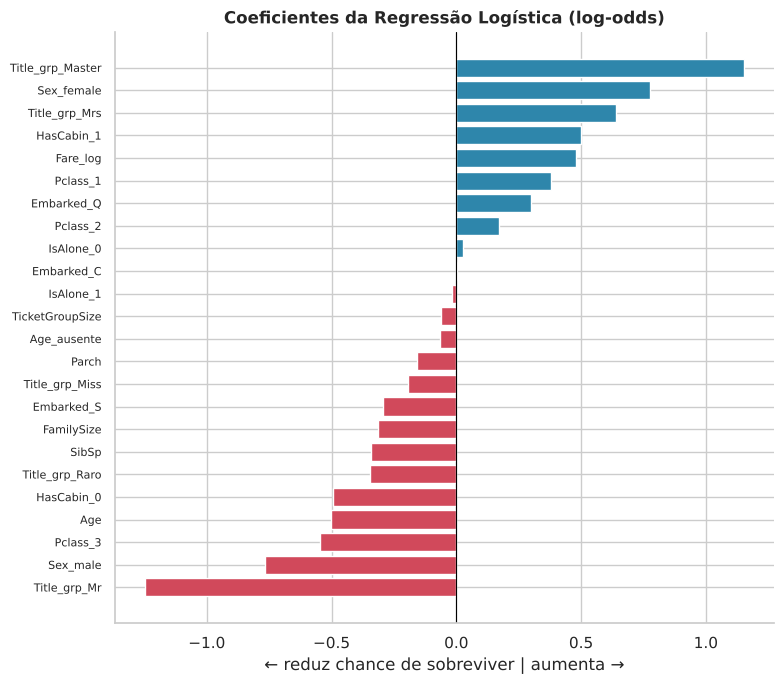

In [38]:
lr_pipe = tunados["Regressão Logística"].best_estimator_
nomes = lr_pipe.named_steps["pre"].get_feature_names_out()
nomes = [n.replace("num__", "").replace("cat__", "").replace("oh__", "") for n in nomes]
coefs = pd.Series(lr_pipe.named_steps["modelo"].coef_[0], index=nomes).sort_values()
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(coefs.index, coefs.values, color=[COR_SOBREVIVEU if v > 0 else COR_MORREU for v in coefs.values])
ax.axvline(0, color="black", lw=0.8)
ax.set(title="Coeficientes da Regressão Logística (log-odds)", xlabel="← reduz chance de sobreviver | aumenta →")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

### 10.3 Escolha do limiar de decisão
O limiar de 0,5 é uma convenção. Usando **previsões fora da amostra obtidas no treino** (validação cruzada), vemos como acurácia e F1 variam, sem espiar o teste.

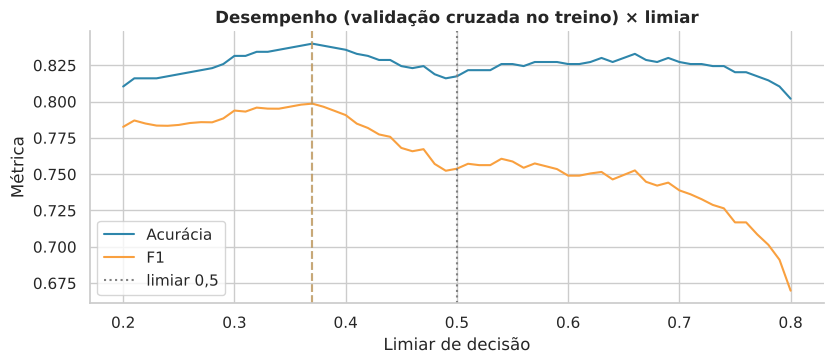

Limiar que maximiza acurácia (treino/CV): 0.37 | maximiza F1: 0.37
No teste → acurácia com 0,50: 0.804 | com 0.37: 0.799


In [39]:
oof = cross_val_predict(melhor, X_tr, y_tr, cv=cv_grid, method="predict_proba")[:, 1]
limiares = np.linspace(0.2, 0.8, 61)
acc_l = [accuracy_score(y_tr, oof >= t) for t in limiares]
f1_l = [f1_score(y_tr, oof >= t) for t in limiares]
t_acc, t_f1 = limiares[int(np.argmax(acc_l))], limiares[int(np.argmax(f1_l))]

fig, ax = plt.subplots(figsize=(8.5, 3.8))
ax.plot(limiares, acc_l, label="Acurácia", color=COR_SOBREVIVEU); ax.plot(limiares, f1_l, label="F1", color="#f9a03f")
ax.axvline(0.5, color="gray", ls=":", label="limiar 0,5")
ax.axvline(t_acc, color=COR_SOBREVIVEU, ls="--", alpha=0.6); ax.axvline(t_f1, color="#f9a03f", ls="--", alpha=0.6)
ax.set(title="Desempenho (validação cruzada no treino) × limiar", xlabel="Limiar de decisão", ylabel="Métrica"); ax.legend()
plt.tight_layout(); plt.show()
print(f"Limiar que maximiza acurácia (treino/CV): {t_acc:.2f} | maximiza F1: {t_f1:.2f}")
print(f"No teste → acurácia com 0,50: {accuracy_score(y_te, probas_te[nome_melhor] >= 0.5):.3f} | "
      f"com {t_acc:.2f}: {accuracy_score(y_te, probas_te[nome_melhor] >= t_acc):.3f}")

**Leitura:** o limiar que maximiza F1 e acurácia na validação cruzada é ~0,37 (um pouco mais "generoso" com a classe *sobreviveu*, que é a minoritária), mas no teste isso não muda a acurácia de forma relevante. Se o custo de deixar de identificar um sobrevivente fosse maior que o de um falso alarme, baixar o limiar aumentaria o *recall*; é uma decisão de uso, não de estatística.

### 10.4 Análise dos erros: quem o modelo não consegue prever?

In [40]:
analise = df.loc[X_te.index, ["Name", "Sex", "Pclass", "Age", "Title_grp", "Fare", "FamilySize", "Survived"]].copy()
analise["prob"] = probas_te[nome_melhor]
analise["pred"] = (analise["prob"] >= 0.5).astype(int)
analise["erro"] = (analise["pred"] != analise["Survived"]).astype(int)

print("Taxa de erro por grupo (teste):")
tab_err = analise.groupby(["Sex", "Pclass"])["erro"].agg(["mean", "sum", "size"]).rename(columns={"mean": "taxa de erro", "sum": "erros", "size": "n"})
display(tab_err.round(3))

# Erros mais "confiantes": o modelo tinha certeza e errou
analise["confianca_no_erro"] = np.where(analise["pred"] == 1, analise["prob"], 1 - analise["prob"])
print("\nErros mais confiantes:")
display(analise[analise["erro"] == 1].sort_values("confianca_no_erro", ascending=False)
        [["Name", "Sex", "Pclass", "Age", "Survived", "prob"]].head(8).round(2).reset_index(drop=True))

Taxa de erro por grupo (teste):


taxa de erro  erros   n
Sex    Pclass                         
female 1              0.067      1  15
       2              0.056      1  18
       3              0.286      8  28
male   1              0.433     13  30
       2              0.188      3  16
       3              0.125      9  72


Erros mais confiantes:


,Name,Sex,Pclass,Age,Survived,prob
0,"Harris, Mr. George",male,2,62.0,1,0.02
1,"Tornquist, Mr. William Henry",male,3,25.0,1,0.02
2,"Hedman, Mr. Oskar Arvid",male,3,27.0,1,0.02
3,"Allison, Miss. Helen Loraine",female,1,2.0,0,0.97
4,"Butt, Major. Archibald Willingham",male,1,45.0,0,0.95
5,"Minahan, Dr. William Edward",male,1,44.0,0,0.94
6,"Johannesen-Bratthammer, Mr. Bernt",male,3,NaN,1,0.07
7,"Frolicher-Stehli, Mr. Maxmillian",male,1,60.0,1,0.09


**Leitura:** os erros se concentram onde o desfecho foi mais próximo de "cara ou coroa": **homens de 1ª classe** (43% de erro, 13 de 30; cerca de um terço sobreviveu) e **mulheres de 3ª classe** (29%). Entre os erros mais confiantes estão uma menina de 2 anos da 1ª classe que morreu (família Allison) e homens de 3ª classe que sobreviveram. O que resta de incerteza parece vir de **acaso e circunstâncias** (posição no navio, acesso a um bote, decisões individuais) que não estão nos dados. Daí o teto de acurácia.

### 10.5 Curva de aprendizado: mais dados ajudariam?

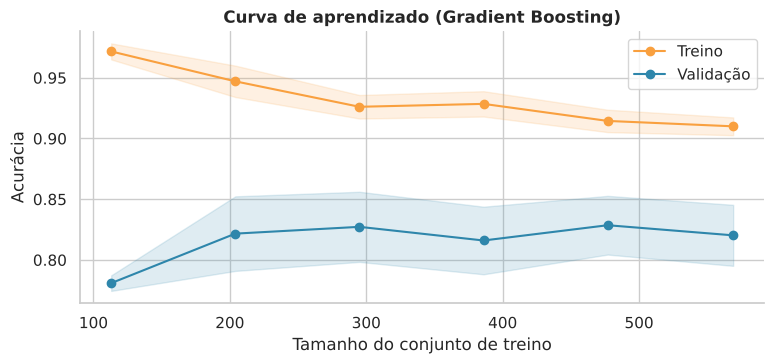

In [41]:
tam, tr_sc, va_sc = learning_curve(melhor, X_tr, y_tr, cv=cv_grid, train_sizes=np.linspace(0.2, 1.0, 6),
                                   scoring="accuracy", n_jobs=-1, random_state=SEED)
fig, ax = plt.subplots(figsize=(8, 3.8))
for sc, nome, cor in [(tr_sc, "Treino", "#f9a03f"), (va_sc, "Validação", COR_SOBREVIVEU)]:
    ax.plot(tam, sc.mean(axis=1), "o-", color=cor, label=nome)
    ax.fill_between(tam, sc.mean(axis=1) - sc.std(axis=1), sc.mean(axis=1) + sc.std(axis=1), alpha=0.15, color=cor)
ax.set(title=f"Curva de aprendizado ({nome_melhor})", xlabel="Tamanho do conjunto de treino", ylabel="Acurácia"); ax.legend()
plt.tight_layout(); plt.show()

**Leitura:** a acurácia de validação estabiliza em ~82% a partir de ~300 passageiros, enquanto a de treino cai de 97% para 91%. A lacuna persistente (~9 p.p.) indica algum **sobreajuste**, e que **mais dados do mesmo tipo trariam pouco ganho**; para avançar seria preciso informação nova (por exemplo, localização da cabine ou convés de embarque nos botes).

## 11. 📝 Resenha dos resultados

### Panorama
Os dados cobrem **891 passageiros** (uma amostra dos cerca de 2.200 a bordo); **38,4% sobreviveram**. A principal conclusão é que o desfecho foi determinado, em larga medida, por **quem a pessoa era** (sexo, idade, classe social) e **com quem viajava**, e menos por variáveis "técnicas" como o porto de embarque.

### Respostas às perguntas do início

**1. Sexo, idade e classe: o que mais pesou?**
* **Sexo** foi o fator mais forte: 74% das mulheres sobreviveram contra 19% dos homens (risco relativo 3,9; *odds ratio* bruto 12,4; IC 95%: 8,9–17,1). Ajustado pelos demais fatores, o OR é ~14.
* **Classe** vem em seguida: 63% (1ª), 47% (2ª) e 24% (3ª). Ajustado, só a 3ª classe se distingue da 1ª (OR 0,28).
* **Sexo e classe interagem** (p ≈ 8×10⁻⁸): 97% das mulheres de 1ª e 92% das de 2ª sobreviveram, mas apenas 50% das de 3ª. Aos 30 anos, o modelo prevê 45% para uma mulher de 3ª classe e 50% para um homem de 1ª, ou seja, **a classe social "comprou" a proteção do gênero**. Entre os homens, só 14–16% (2ª/3ª) e 37% (1ª) sobreviveram.
* **Idade** age de forma não linear e depende do sexo: crianças de 0–4 anos tiveram 68% de sobrevivência, e entre os homens a chance cai com a idade (cada década a mais reduz as *odds* em ~34% no modelo ajustado). A idade isolada praticamente não separa os grupos (P(superioridade) = 0,47; p = 0,16), pois seu efeito se esconde atrás do sexo e da faixa etária. "Mulheres e crianças primeiro" vale, mas **muito menos na 3ª classe**: apenas 42% das crianças de 3ª classe sobreviveram.

**2. Tarifa e porto de embarque**
* A **tarifa** está associada à sobrevivência (P(superioridade) = 0,69; 22% de sobrevivência no quintil mais baixo vs. 64% no mais alto), mas no modelo ajustado perde significância (OR = 1,35 por unidade de log; p = 0,08): seu efeito é largamente absorvido por classe, cabine e tamanho do grupo. Dentro da 1ª classe o gradiente persiste (44% → 77% do tercil mais baixo ao mais alto), o que provavelmente reflete cabine/localização.
* O **porto** é um caso clássico de **confusão**: Cherbourg parece muito melhor (55% vs. 34% em Southampton, OR bruto 2,44) porque 51% dos seus passageiros eram de 1ª classe. Controlando classe e sexo o OR cai para 1,81, e no modelo completo para 1,36 (p = 0,21, não significativo). Resta, no máximo, um efeito pequeno.

**3. Família**
* Há um padrão em **"U invertido"**: viajar sozinho (30%) é pior que família de 2–4 pessoas (55–72%); famílias com 5 ou mais, pior ainda (16%). O mesmo vale para o número de pessoas no mesmo bilhete.
* No modelo ajustado, a única penalidade que sobrevive é a de **famílias grandes (OR = 0,08 vs. quem viajava só)**; famílias pequenas deixam de se distinguir de quem viajava sozinho depois de controlar sexo, classe e cabine.
* Pessoas com o mesmo bilhete tendem a **compartilhar o destino** (76% dos pares com o mesmo desfecho vs. ~52,5% esperado ao acaso; p < 0,001), coerente com evacuações em grupo, embora parte disso seja homogeneidade (mesmo sexo/classe).

**4. É possível prever a sobrevivência?**
* **Sim, mas só até certo ponto.** Em validação cruzada repetida (5×3), todos os modelos (regressão logística, SVM, random forest, gradient boosting) ficaram entre **81% e 83%** de acurácia e **AUC de 0,86 a 0,89**, estatisticamente empatados. Isso é apenas **~2–5 pontos acima da regra de uma linha** "mulher sobrevive, homem morre" (≈ 79%).
* No conjunto de teste (n = 179), o modelo escolhido pela validação (Gradient Boosting) obteve 80,4% (IC95% 74–86%) e a regressão logística 84,4%; essa diferença está dentro do ruído amostral (±6 p.p.). A diferença do modelo escolhido para a regra de uma linha **não foi estatisticamente significativa** (McNemar exato, p ≈ 0,44).
* As variáveis que mais sustentam a previsão são **título** (que sintetiza sexo, idade e estado civil), **sexo**, **tamanho do grupo de bilhete** e **classe**. Tarifa, porto, SibSp e Parch contribuem praticamente nada depois dessas.
* Os erros concentram-se em **homens de 1ª classe** e **mulheres de 3ª classe**, grupos com desfecho próximo de "cara ou coroa" nos dados; a curva de aprendizado mostra que mais dados do mesmo tipo trariam pouco ganho. Para melhorar seria preciso **informação nova** (por exemplo, localização da cabine e distância dos botes).

### Boas práticas adotadas neste notebook
* Taxas sempre com **intervalos de confiança**, para não superinterpretar grupos pequenos.
* Testes adequados à natureza dos dados (**qui-quadrado + V de Cramér**, Mann-Whitney, regressão logística com *odds ratios* e testes de razão de verossimilhança).
* Imputação da idade por **título × classe**, realizada **dentro do pipeline** para evitar vazamento de dados.
* Novos atributos (título, grupo de bilhete, cabine/convés, categoria de família) e investigação explícita de **confusão** (porto × classe) e **interação** (sexo × classe).
* Modelagem com linhas de base, validação cruzada repetida, ajuste de hiperparâmetros, calibração, importância por permutação e análise de erros, deixando claro que as diferenças entre modelos são pequenas diante da incerteza.

### Limitações
* **Amostra** de 891 passageiros (o teste tem apenas 179): diferenças de poucos pontos percentuais são ruído.
* **20% das idades** foram imputadas e **77% das cabines** são desconhecidas (e a ausência é informativa: relacionada à classe).
* Análise **observacional**: os *odds ratios* descrevem associações, não causas. O desfecho dependeu de fatores não medidos (posição no navio, acesso aos botes, decisões individuais, comportamento da tripulação).
* A contagem de passageiros por bilhete (`TicketGroupSize`) usa todos os 891 registros, o que não vaza o desfecho, mas depende de o conjunto ser representativo dos grupos reais.
* Não foi feita nenhuma correção para múltiplas comparações; os p-valores devem ser lidos como evidência descritiva, não como confirmação.

### Conclusão
O Titanic mostra, em dados, um padrão de **"proteção desigual"**: valeu a regra *mulheres e crianças primeiro*, mas a proteção foi **fortemente modulada pela classe social**: uma mulher de 3ª classe tinha chance semelhante à de um homem de 1ª, e uma criança de 3ª classe tinha bem menos chance que uma de 2ª. Grande parte do que parece ser efeito de porto ou tarifa é, na verdade, efeito de classe. Modelos sofisticados quase não superam uma regra simples (sexo), e o restante da variação parece ser circunstância e acaso, não capturados pelos dados.

---

**Como citar este material**

> COIMBRA, Paulo C. **Titanic: da análise exploratória à predição de sobrevivência**: material didático (notebook, página de aula e artigo). Juiz de Fora: UFJF, 2026. Disponível em: https://github.com/pauloccoimbra/titanic-eda-ml-aula.

```bibtex
@misc{coimbra2026titanic,
  author = {Coimbra, Paulo C.},
  title  = {Titanic: da an{\'a}lise explorat{\'o}ria {\`a} predi{\c c}{\~a}o de sobreviv{\^e}ncia: material did{\'a}tico},
  year   = {2026},
  howpublished = {\url{https://github.com/pauloccoimbra/titanic-eda-ml-aula}},
  note   = {Licen{\c c}as: MIT (c{\'o}digo) e CC BY 4.0 (textos)}
}
```
Licenças: código sob **MIT**; textos, figuras e comentários sob **CC BY 4.0**. Dados: `train.csv` da competição [Titanic do Kaggle](https://www.kaggle.com/competitions/titanic), de uso educacional.